In [1]:
!git clone https://github.com/henrybattley/hebbian_cnn_experiments.git

Cloning into 'hebbian_cnn_experiments'...
remote: Enumerating objects: 74, done.
remote: Counting objects: 100% (74/74), done.
remote: Compressing objects: 100% (49/49), done.
remote: Total 74 (delta 24), reused 71 (delta 21), pack-reused 0 (from 0)
Receiving objects: 100% (74/74), 21.37 MiB | 11.02 MiB/s, done.
Resolving deltas: 100% (24/24), done.


In [1]:
%ls

hebbian_cnn_experiments/  sample_data/


In [1]:
%cd hebbian_cnn_experiments
!git pull

/content/hebbian_cnn_experiments
remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 6 (delta 5), reused 6 (delta 5), pack-reused 0 (from 0)
Unpacking objects: 100% (6/6), 599 bytes | 299.00 KiB/s, done.
From https://github.com/henrybattley/hebbian_cnn_experiments
   ecf5d28..1f8c566  main       -> origin/main
Updating ecf5d28..1f8c566
Fast-forward
 Hebbian_Code/hebbian_config.py    | 3 ++-
 Hebbian_Code/models/model_hebb.py | 6 +++---
 2 files changed, 5 insertions(+), 4 deletions(-)


In [2]:
%cd Hebbian_Code

/content/hebbian_cnn_experiments/Hebbian_Code


In [3]:
import sys
import os

from pathlib import Path


hebbian_root = Path.cwd()
sys.path.insert(0, str(hebbian_root))

In [4]:
%ls

data_processing/   hebbian_experiments.ipynb  __pycache__/
experiment/        hebbian_layers/            requirements.txt
hebbian_config.py  models/                    visualisation/


In [5]:
!pip install torchmetrics

In [6]:
import experiment.experiment_hebbian as hebb
from hebbian_config import get_hebbian_config
from models.model_hebb import Net_Hebbian

In [7]:
import torch
import torch.nn as nn
import random
import numpy as np
import pandas as pd
import torch, torchvision
import torch.nn as nn
from torchsummary import summary
import importlib
import matplotlib.pyplot as plt

In [8]:
import matplotlib.pyplot as plt

plt.rcParams["text.usetex"] = False
plt.rcParams["font.family"] = "DejaVu Sans"

Building SoftHebb model


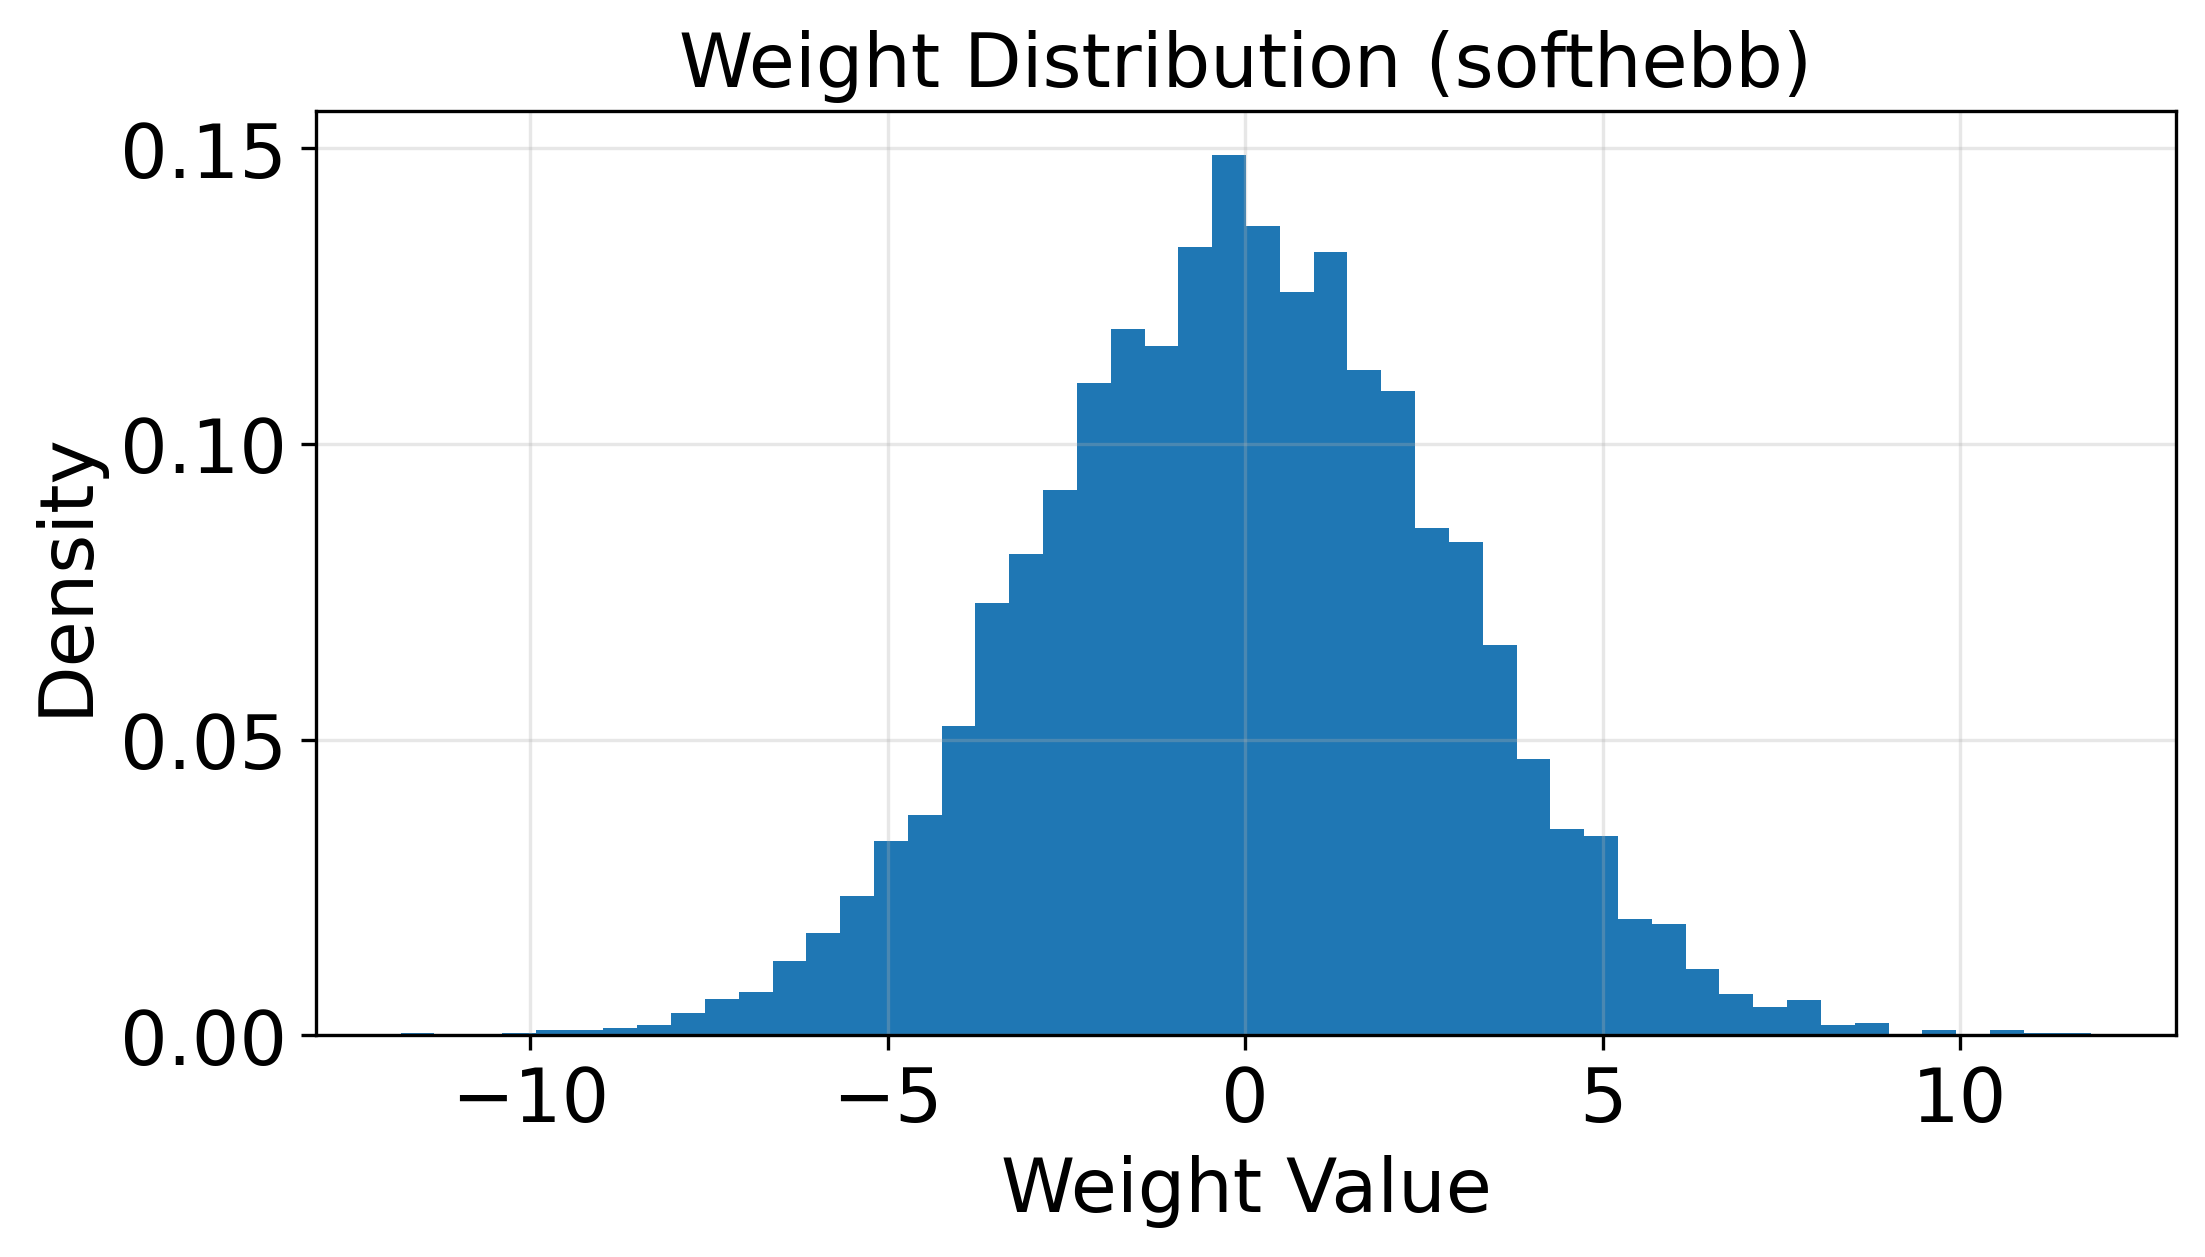

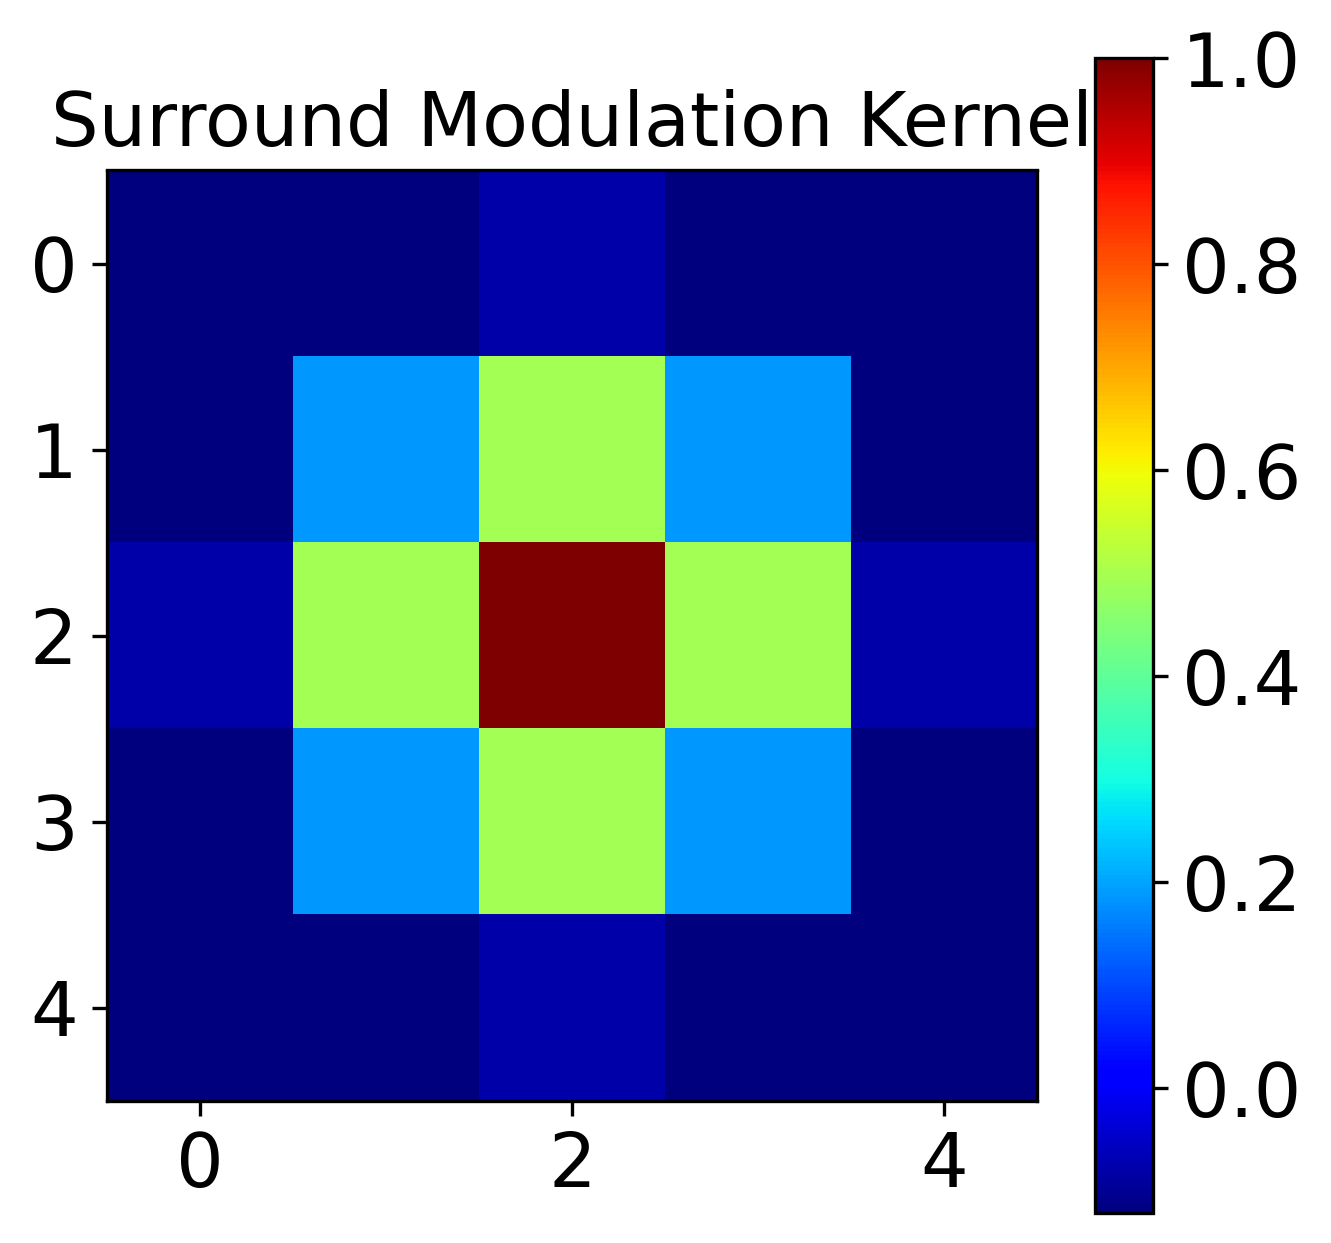

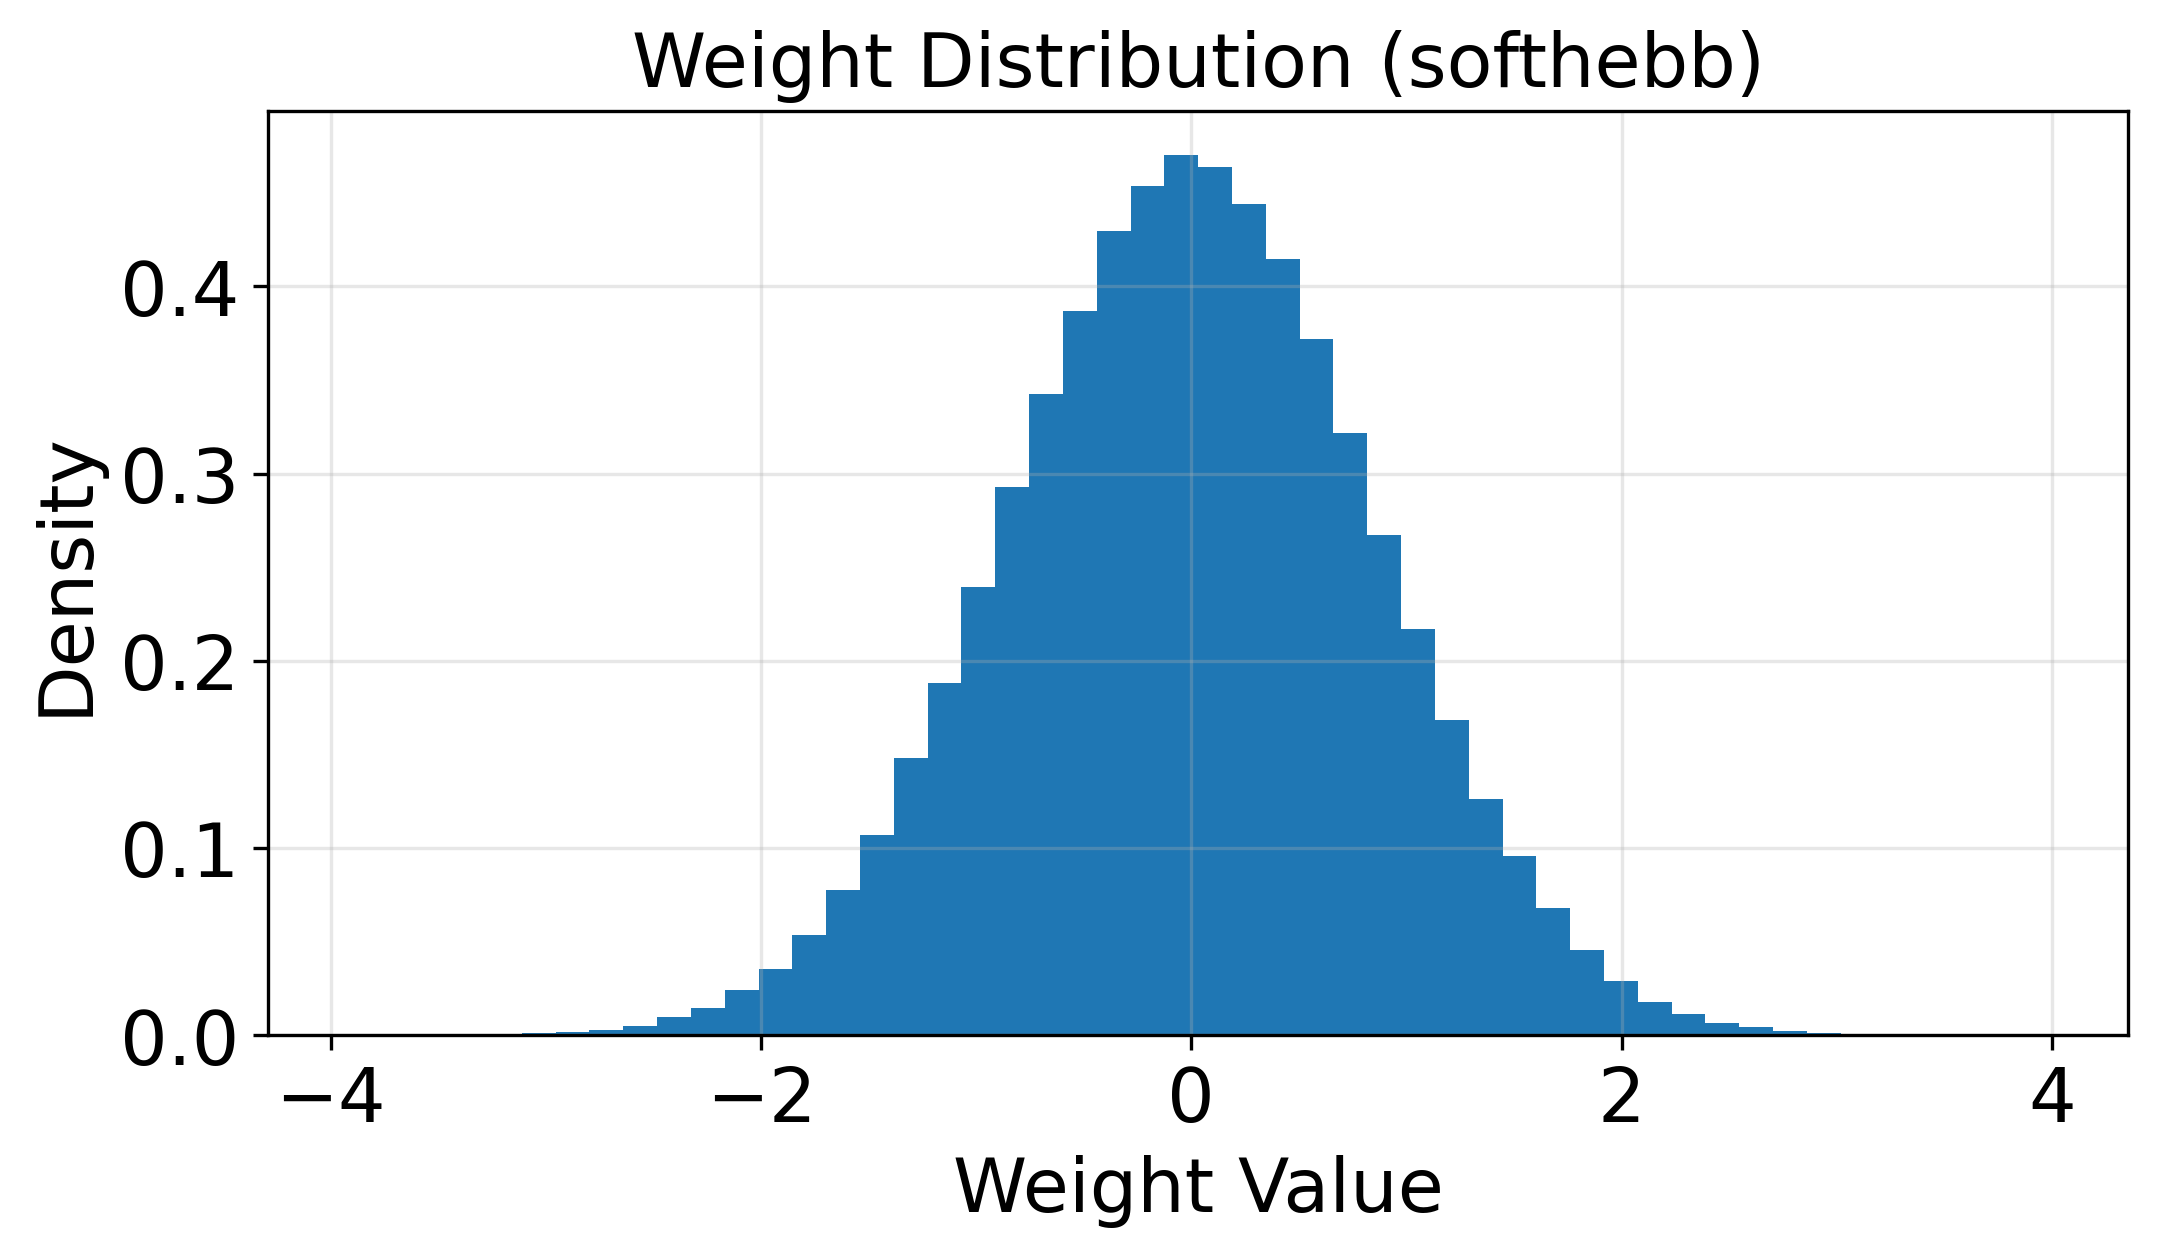

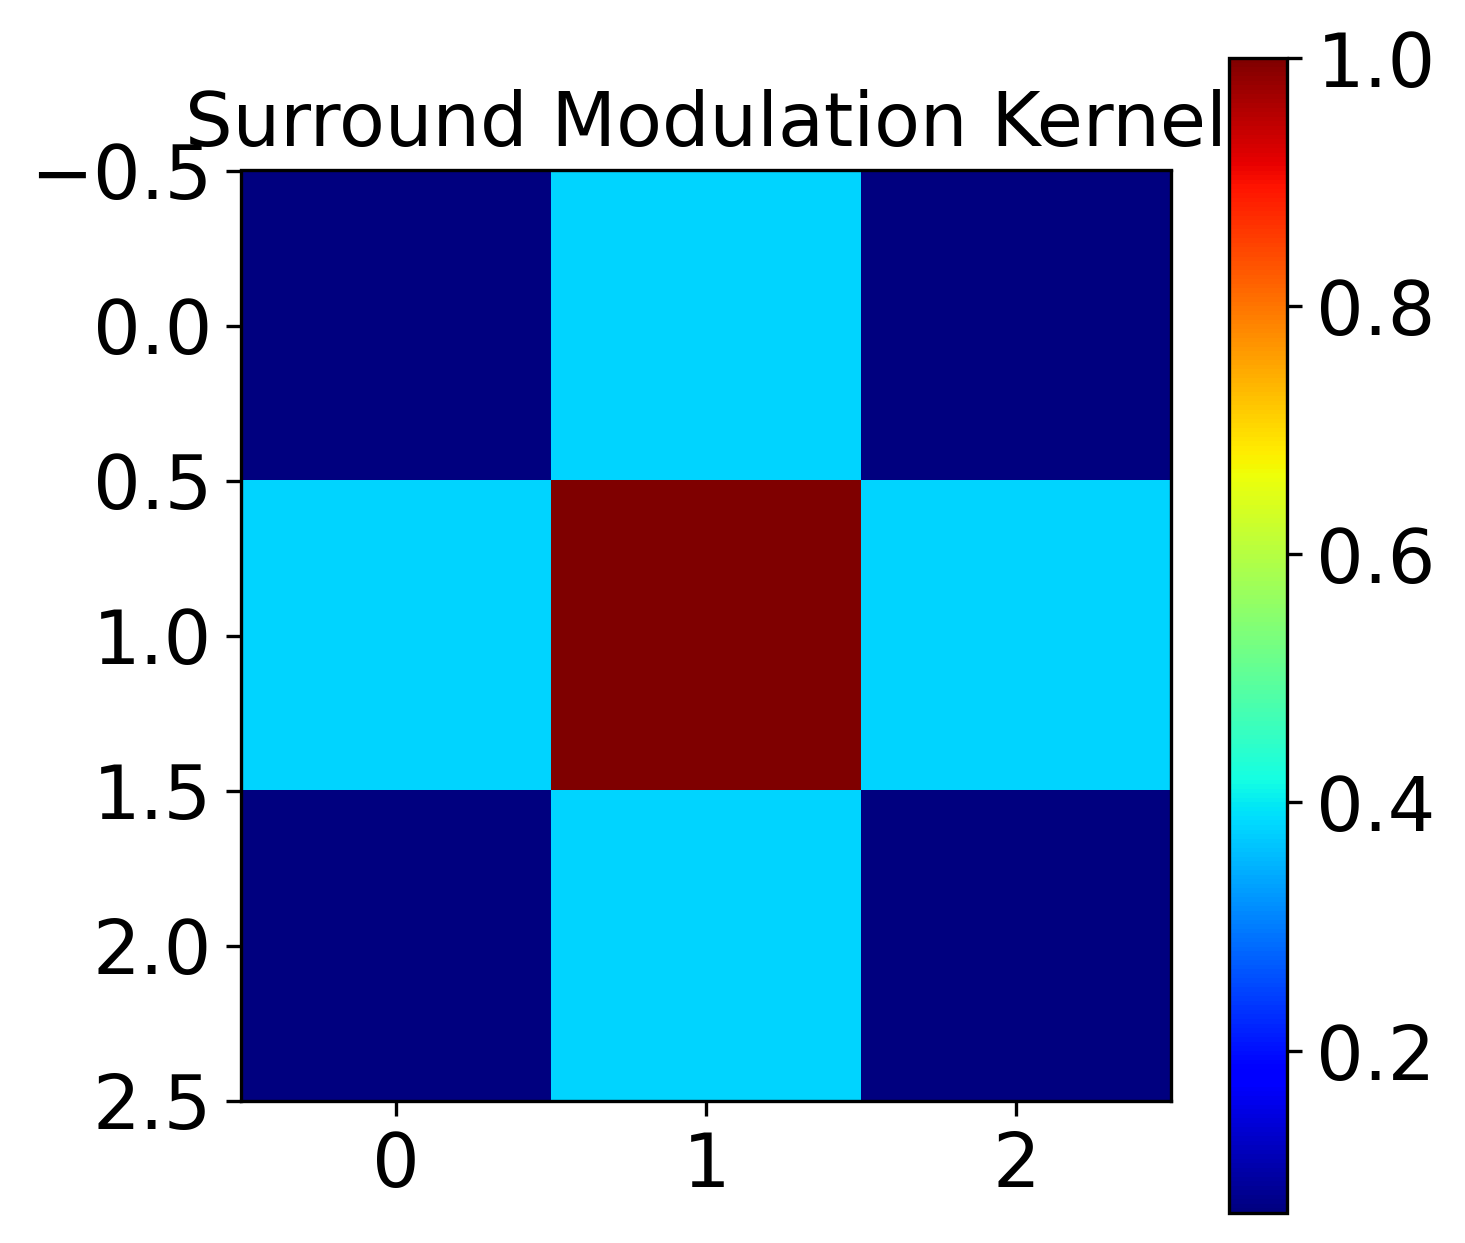

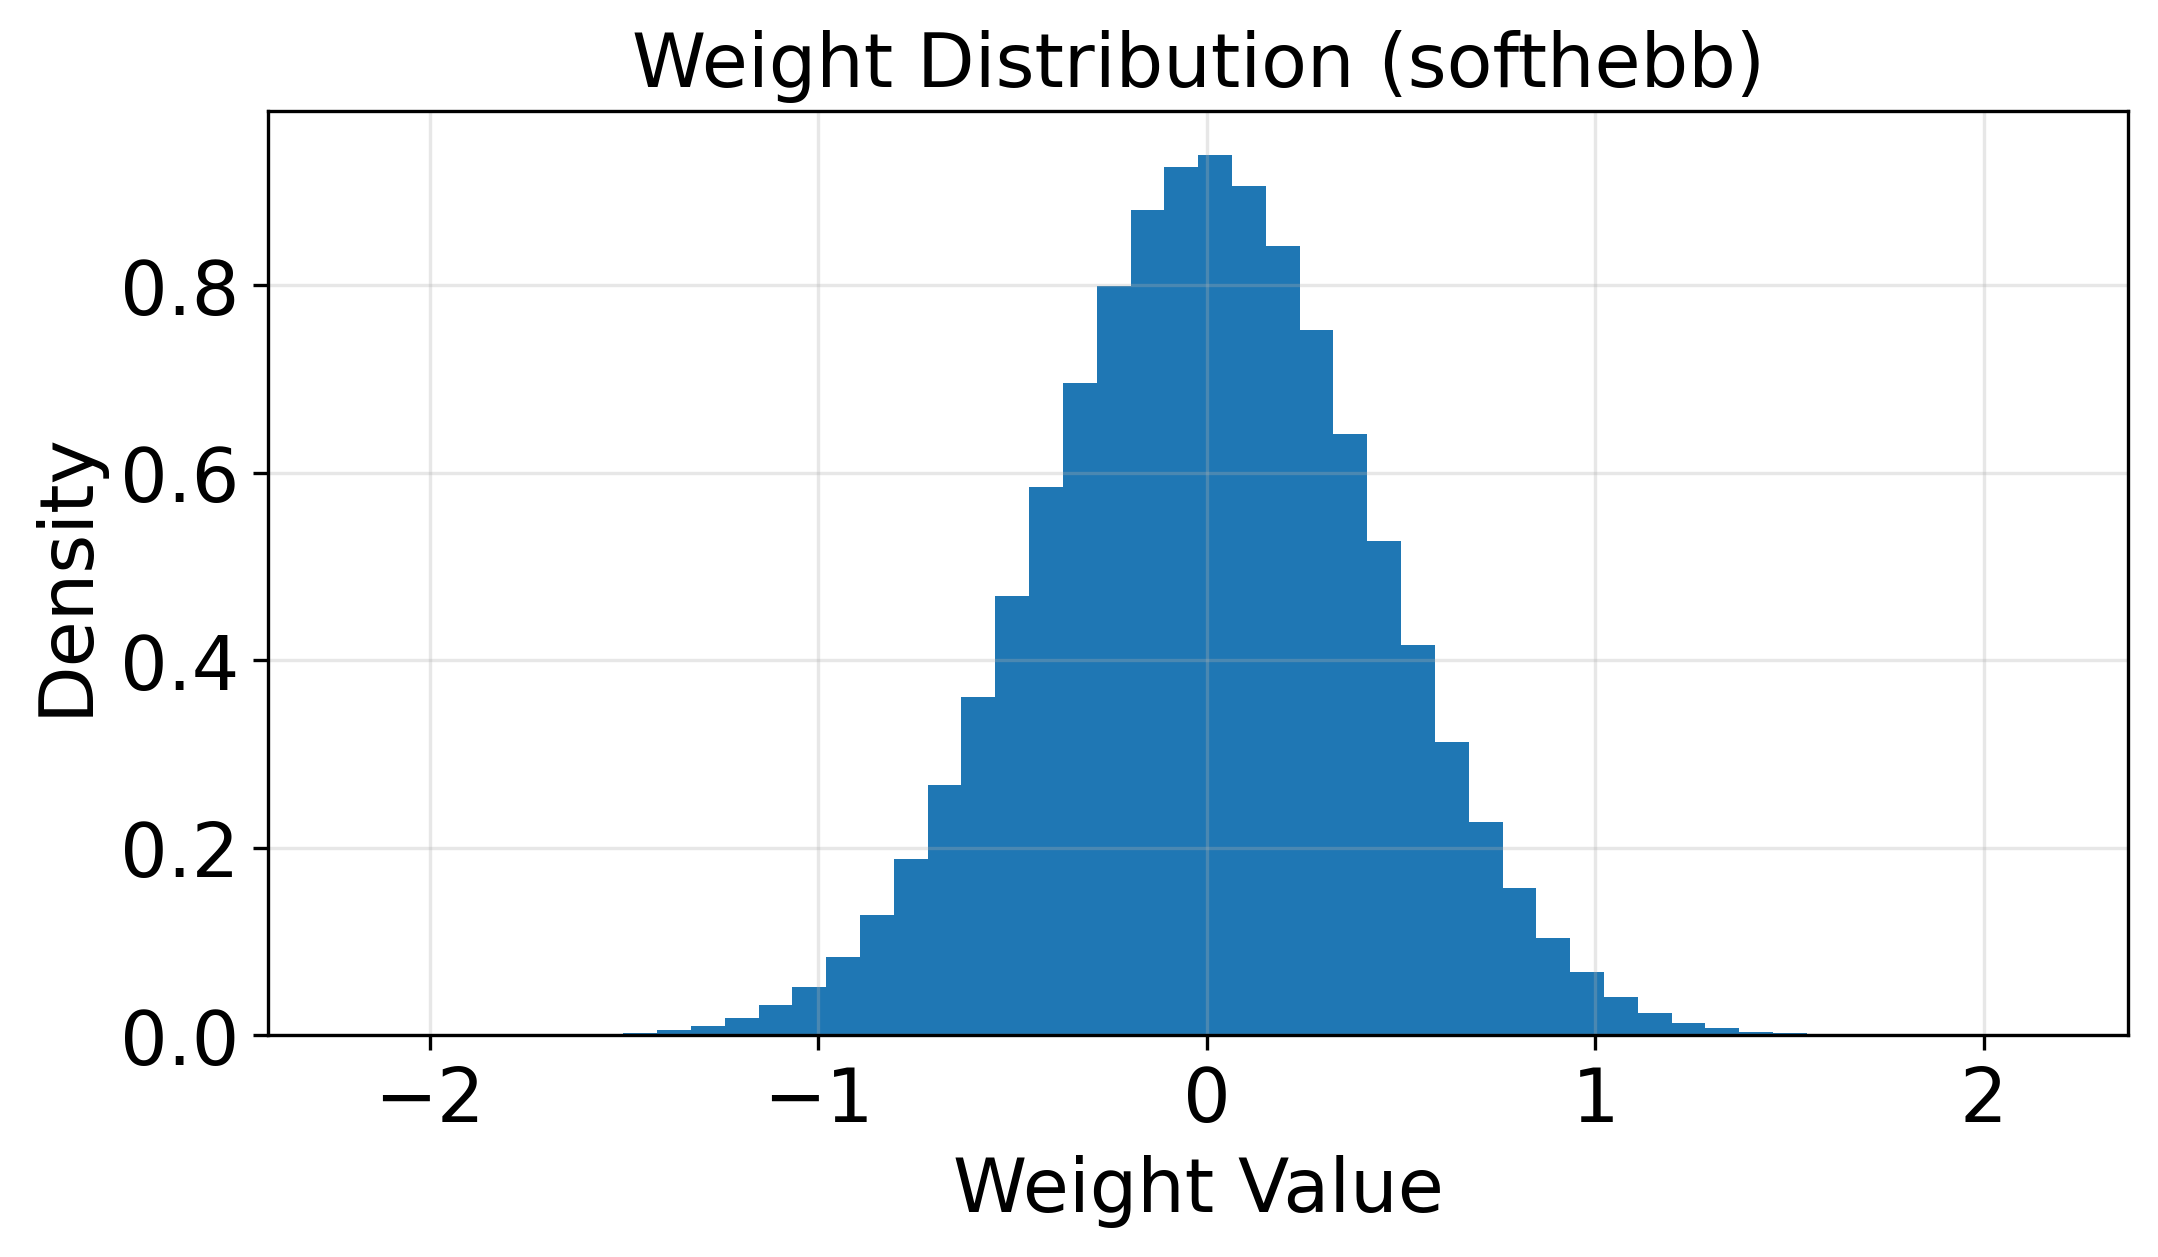

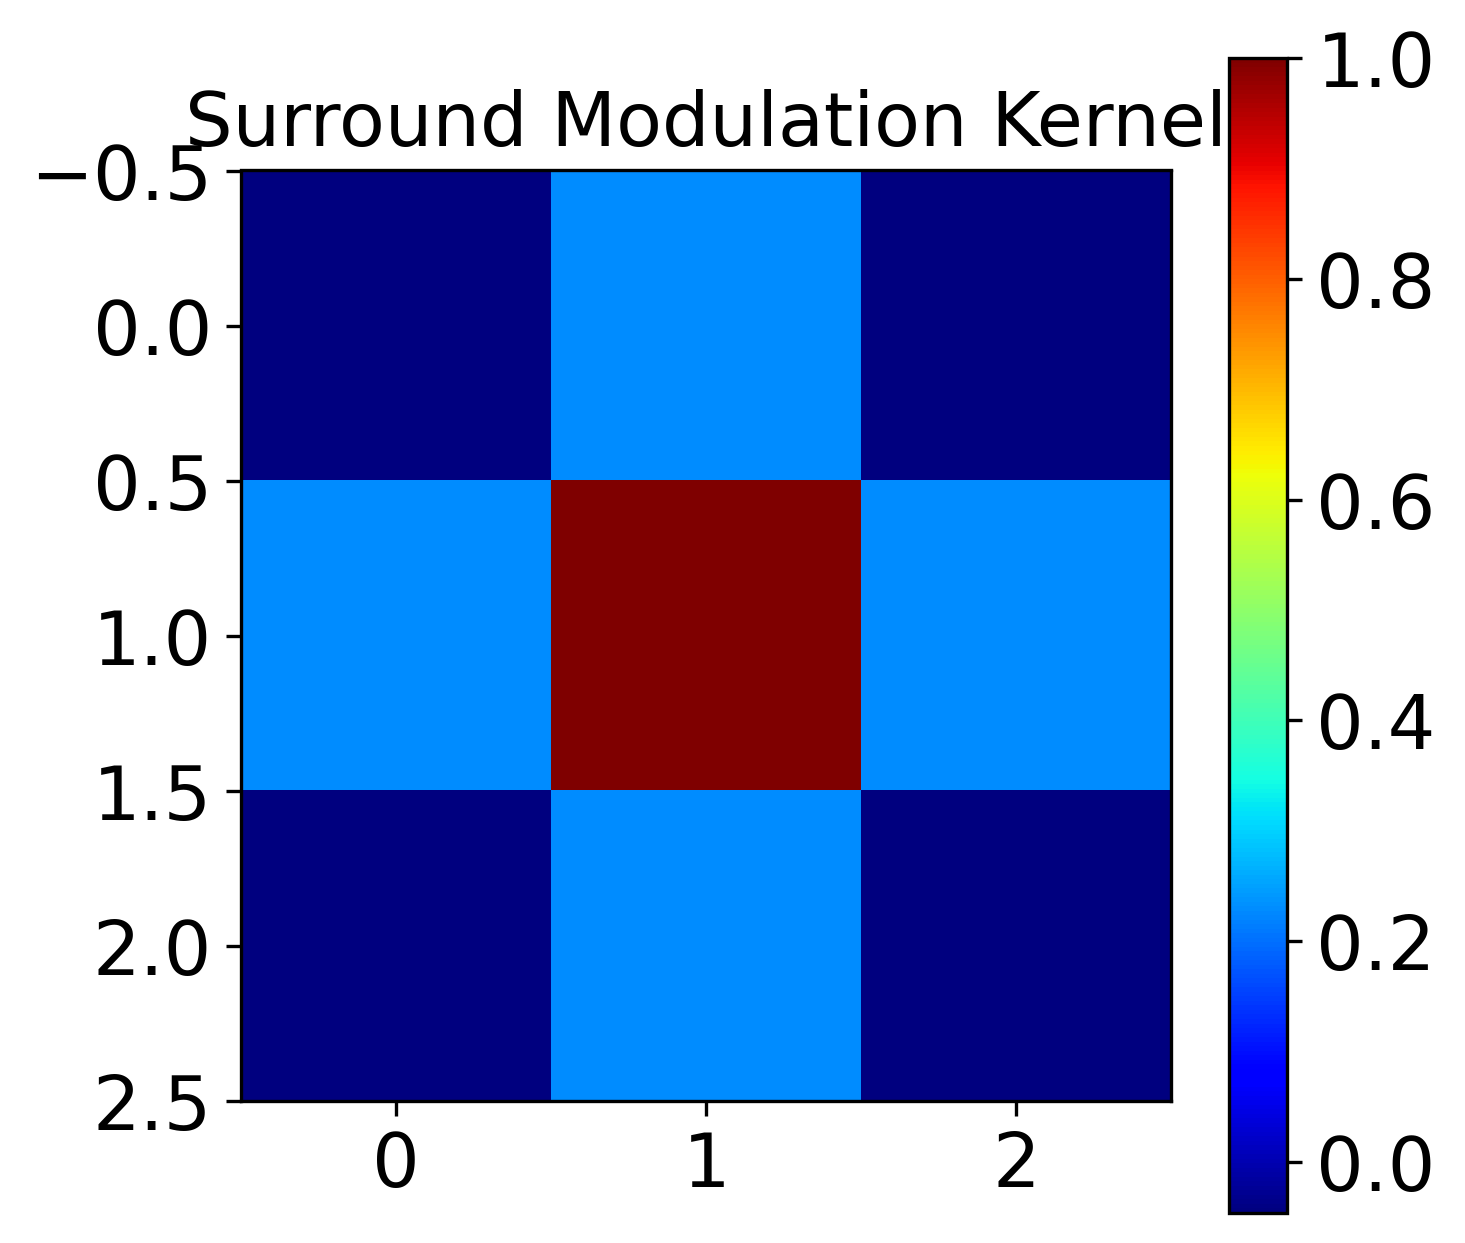

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

hebb_param = get_hebbian_config(version="optimal")

model = Net_Hebbian(
    hebb_params=hebb_param,
    version="softhebb"
).to(device)

In [11]:
hebb_param

{'mode': 'bcm',
 'w_nrm': False,
 'act': Identity(),
 'use_cosine_similarity': True,
 'use_lateral_inhibition': True,
 'top_k': 1,
 'init_method': 'softhebb',
 'patchwise': True,
 'contrast': 1.0,
 'uniformity': False,
 'use_presynaptic_competition': False,
 'presynaptic_competition_type': 'lp_norm',
 'competition_type': 'hard',
 'temporal_window': 500,
 'competition_k': 2,
 'dale': False,
 'use_homeostasis': False}

In [12]:
print("conv1 init:", model.conv1.init_method)
print("conv2 init:", model.conv2.init_method)
print("conv3 init:", model.conv3.init_method)

print("conv1 lr:", model.conv1.lr)
print("conv2 lr:", model.conv2.lr)
print("conv3 lr:", model.conv3.lr)

conv1 init: softhebb
conv2 init: softhebb
conv3 init: softhebb
conv1 lr: 0.08
conv2 lr: 0.005
conv3 lr: 0.01


In [13]:
for i, layer in enumerate(
    [model.conv1, model.conv2, model.conv3], 1
):
    print(f"\nConv {i}")
    print("mode:", layer.mode)
    print("w_nrm:", layer.w_nrm)
    print("k:", getattr(layer, "k", "not stored"))
    print("alpha:", layer.alpha)
    print("t_invert:", layer.t_invert.item())
    print("lr:", layer.lr)
    print("init:", layer.init_method)
    print("cosine:", layer.use_cosine_similarity)
    print("lateral inhibition:", layer.use_lateral_inhibition)


Conv 1
mode: bcm
w_nrm: False
k: not stored
alpha: 1.0
t_invert: 1
lr: 0.08
init: softhebb
cosine: True
lateral inhibition: True

Conv 2
mode: bcm
w_nrm: False
k: not stored
alpha: 1.0
t_invert: 0.6499999761581421
lr: 0.005
init: softhebb
cosine: True
lateral inhibition: True

Conv 3
mode: bcm
w_nrm: False
k: not stored
alpha: 1.0
t_invert: 0.25
lr: 0.01
init: softhebb
cosine: True
lateral inhibition: True


In [14]:
print(model)

Net_Hebbian(
  (bn1): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
  (conv1): HebbianConv2d(
    (act): Identity()
  )
  (pool1): MaxPool2d(kernel_size=4, stride=2, padding=1, dilation=1, ceil_mode=False)
  (activ1): Triangle()
  (bn2): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
  (conv2): HebbianConv2d(
    (act): Identity()
  )
  (pool2): MaxPool2d(kernel_size=4, stride=2, padding=1, dilation=1, ceil_mode=False)
  (activ2): Triangle()
  (bn3): BatchNorm2d(384, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
  (conv3): HebbianConv2d(
    (act): Identity()
  )
  (pool3): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (activ3): Triangle()
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=24576, out_features=10, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


# Get Cifar-10

In [15]:
num_parameters = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print(f"Parameter count: {num_parameters:,}")

Parameter count: 5,893,162


In [16]:
#this is the function we would use to get and transform the data, however since Toronto University servers have incredibly slow download time for cifar-10, again we use the mirror from kaggle
from data_processing.data import get_data

In [17]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ayush1220/cifar10")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cifar10' dataset.
Path to dataset files: /kaggle/input/cifar10


In [18]:
print(os.listdir(path))

['cifar10']


In [19]:
cifar_path = os.path.join(path, "cifar10")

In [20]:
cifar_train_path = os.path.join(cifar_path,"train")

In [21]:
from torchvision import datasets, transforms

raw_dataset = datasets.ImageFolder(
    root=cifar_train_path,
    transform=transforms.ToTensor()
)

In [22]:
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465], #using the same stats for normalisation as provided in the get_data() function
        std=[0.2023, 0.1994, 0.2010] 
    )
])

In [23]:
cifar_train = datasets.ImageFolder(
    root=cifar_train_path,
    transform=transform
)

In [24]:
cifar_loader = torch.utils.data.DataLoader(
    cifar_train,
    batch_size=64,   # uses 64 to reproduce their experiment
    shuffle=True,
    num_workers=2
)

In [25]:
print(len(cifar_train))
print(cifar_train.classes)

50000
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [26]:
x, y = next(iter(cifar_loader))

print(x.shape)
print(x.min())
print(x.max())
print(x.mean(dim=(0,2,3)))
print(x.std(dim=(0,2,3)))

torch.Size([64, 3, 32, 32])
tensor(-2.4291)
tensor(2.7537)
tensor([ 0.0198, -0.0043, -0.0714])
tensor([1.1969, 1.2128, 1.3115])


# Test data loader

In [27]:
cifar_test_path = os.path.join(cifar_path,"test")

In [28]:
#oddly they also use random horisontal flips within the test loader
cifar_test = datasets.ImageFolder(
    root=cifar_test_path,
    transform=transform
)

cifar_test_loader = torch.utils.data.DataLoader(
    cifar_test,
    batch_size=64,
    shuffle=False,
    num_workers=2
)

# The 5 runs...

In [29]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [30]:
seeds = [0, 1, 2, 3, 4]
all_histories = {}

RUN 1/5 | SEED = 0
Building SoftHebb model


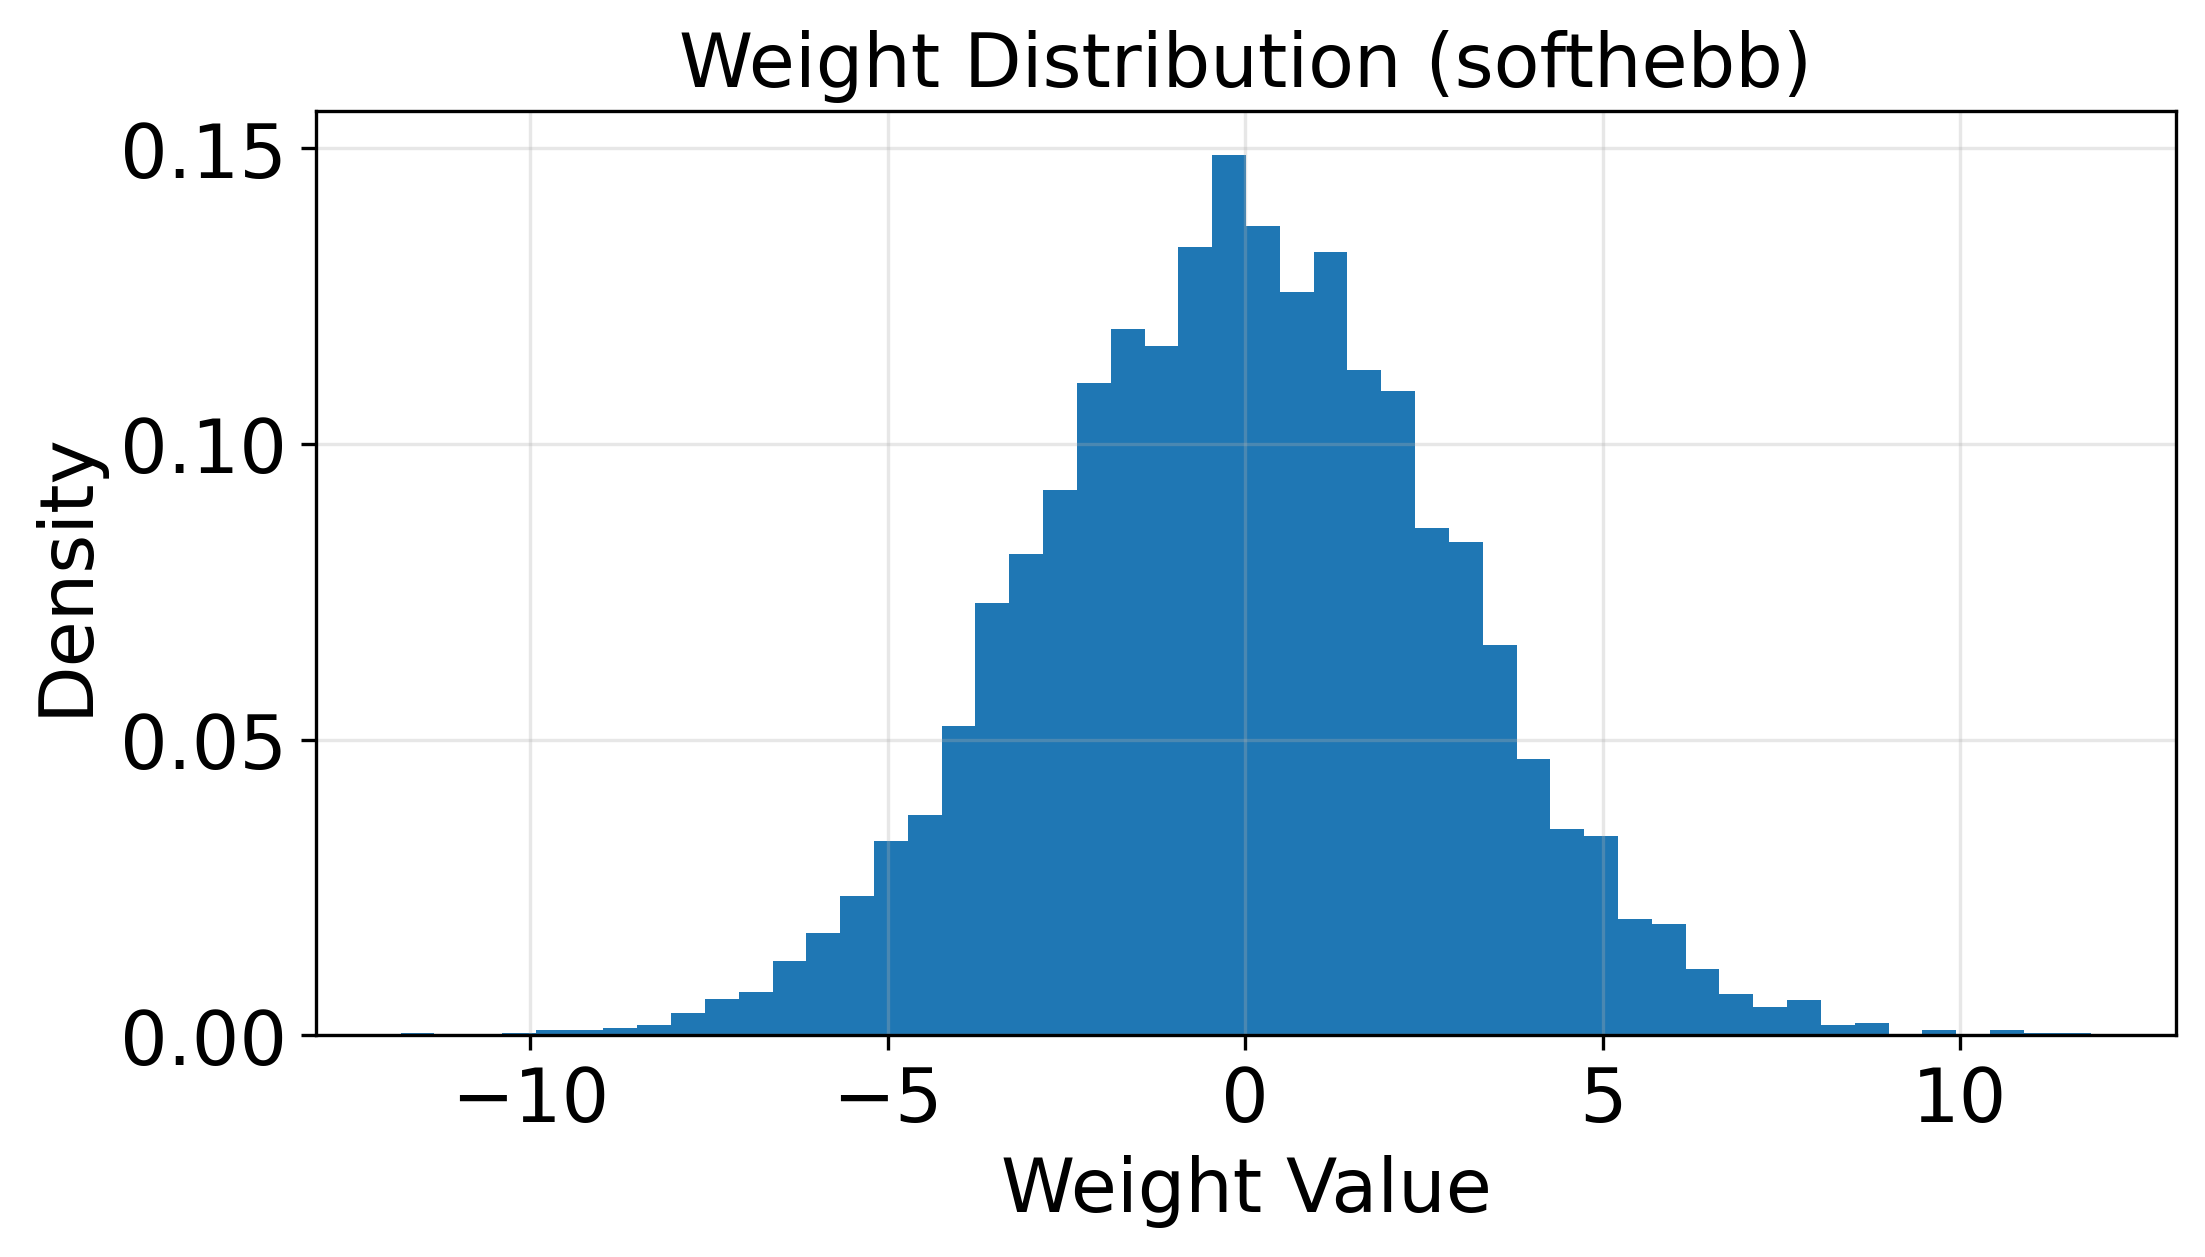

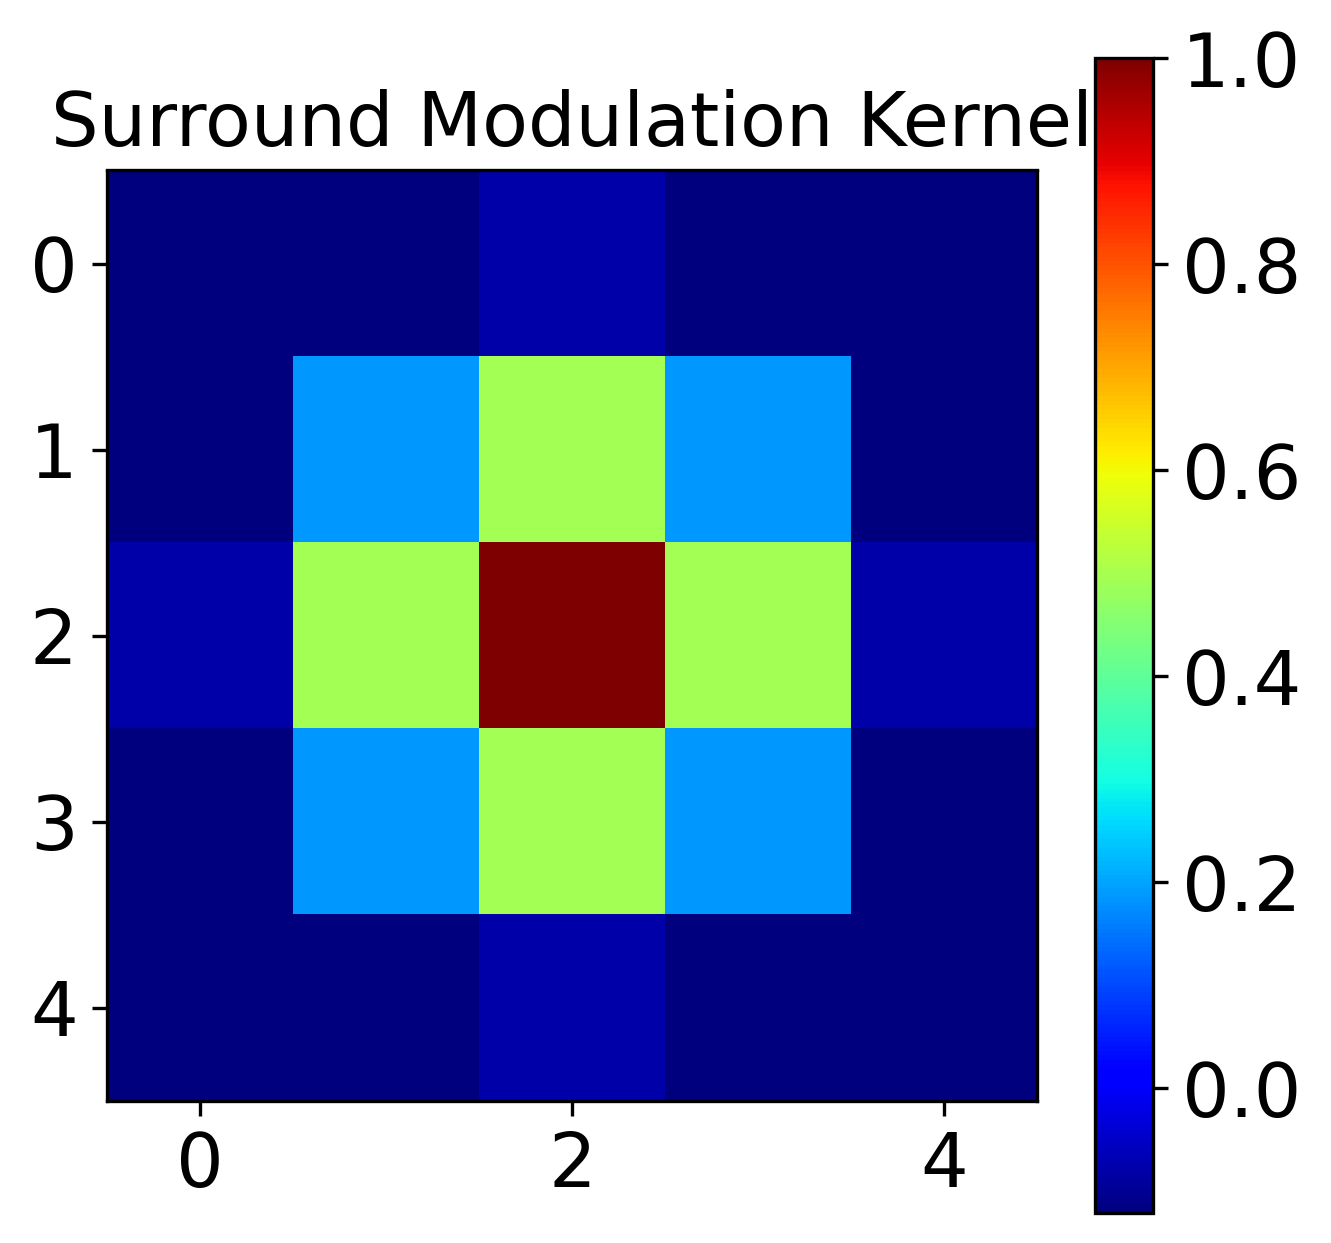

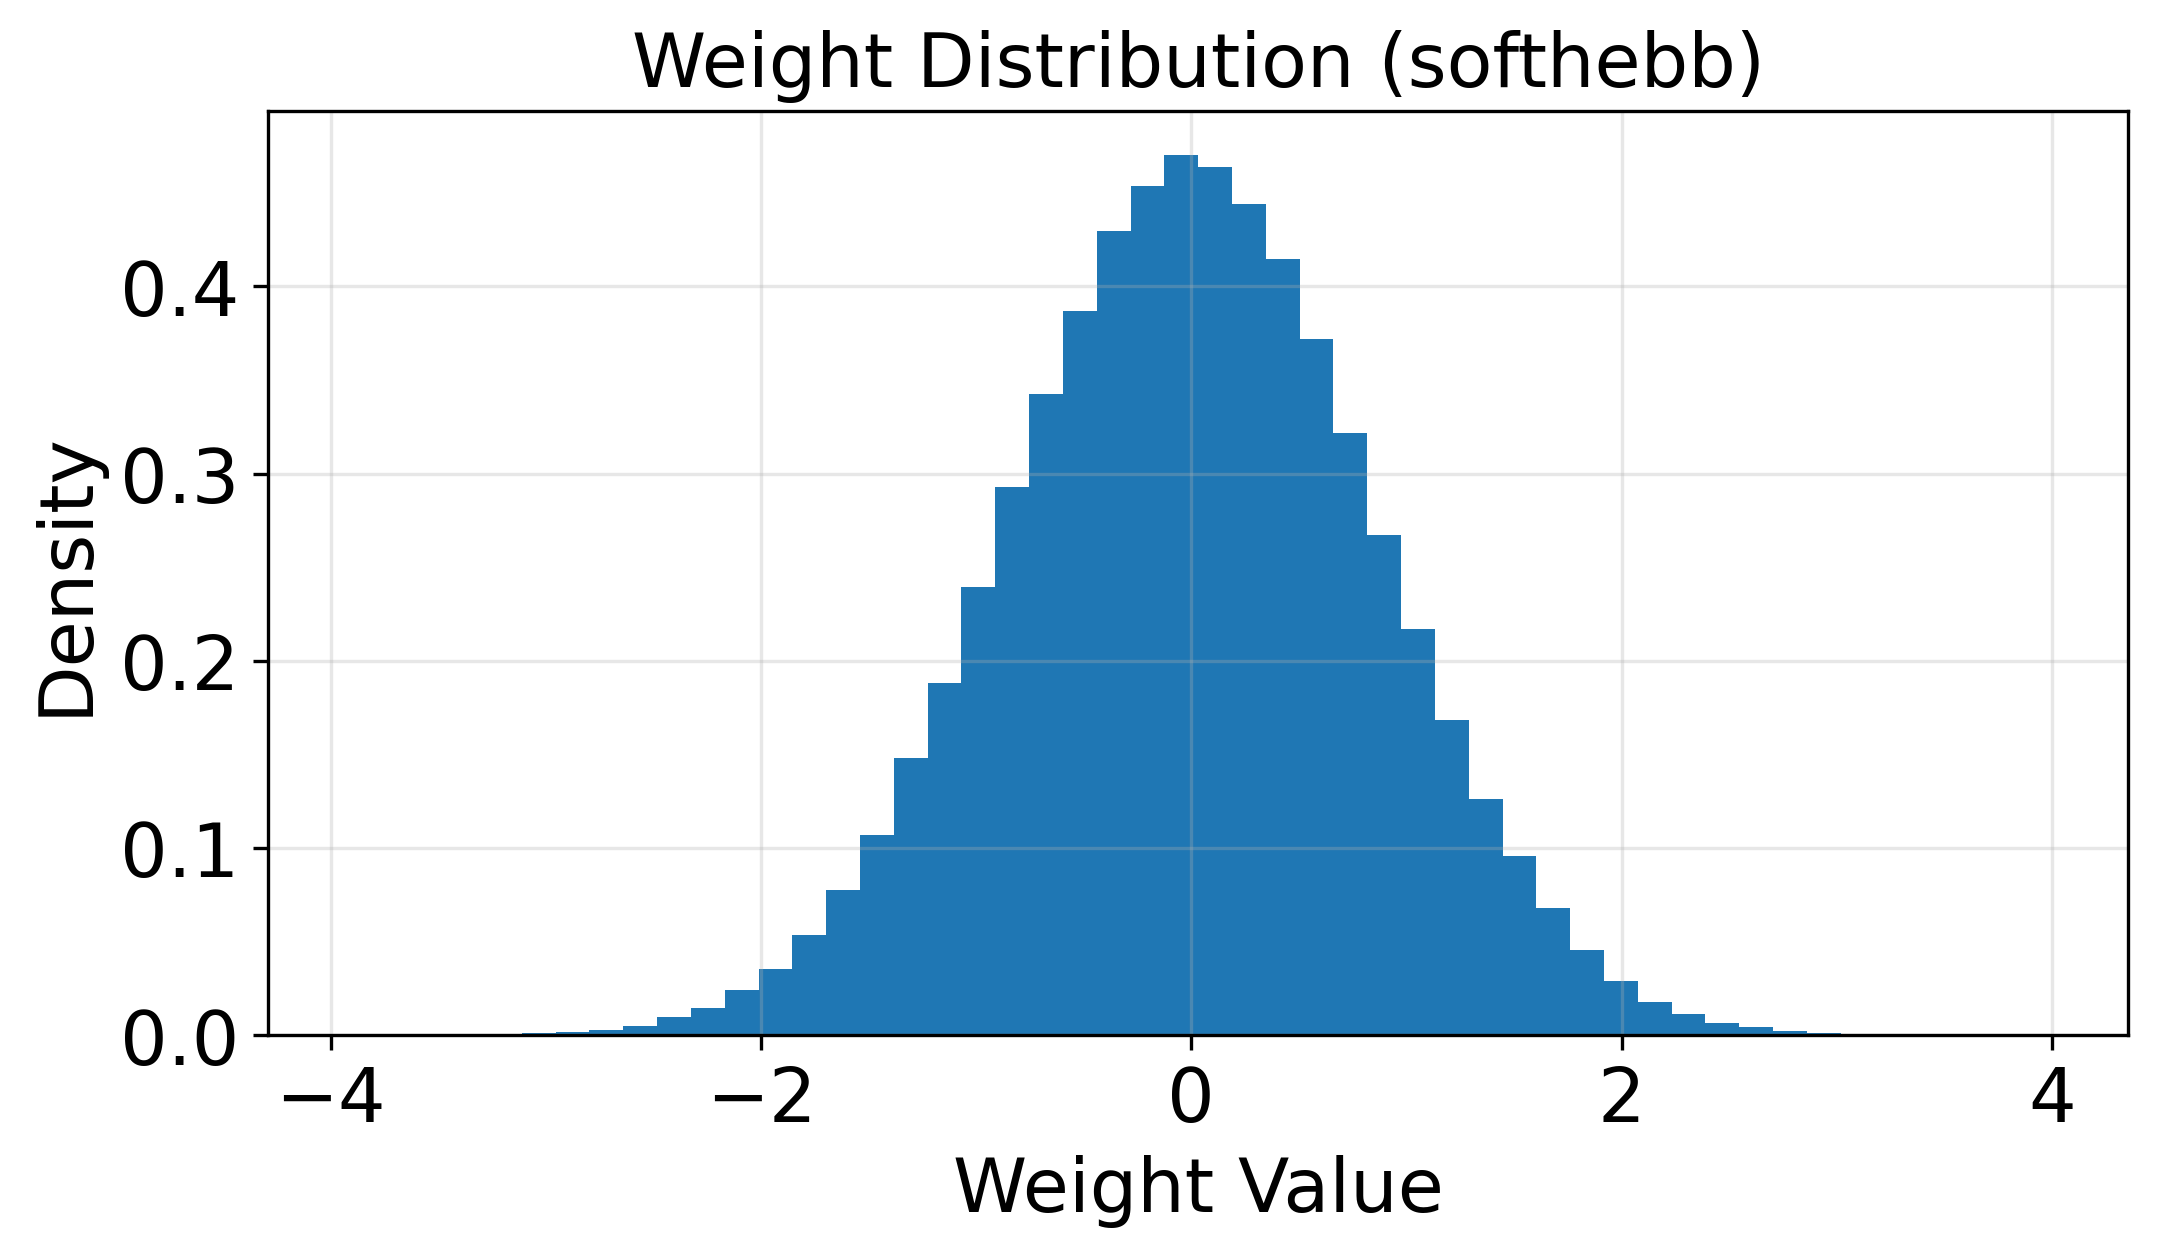

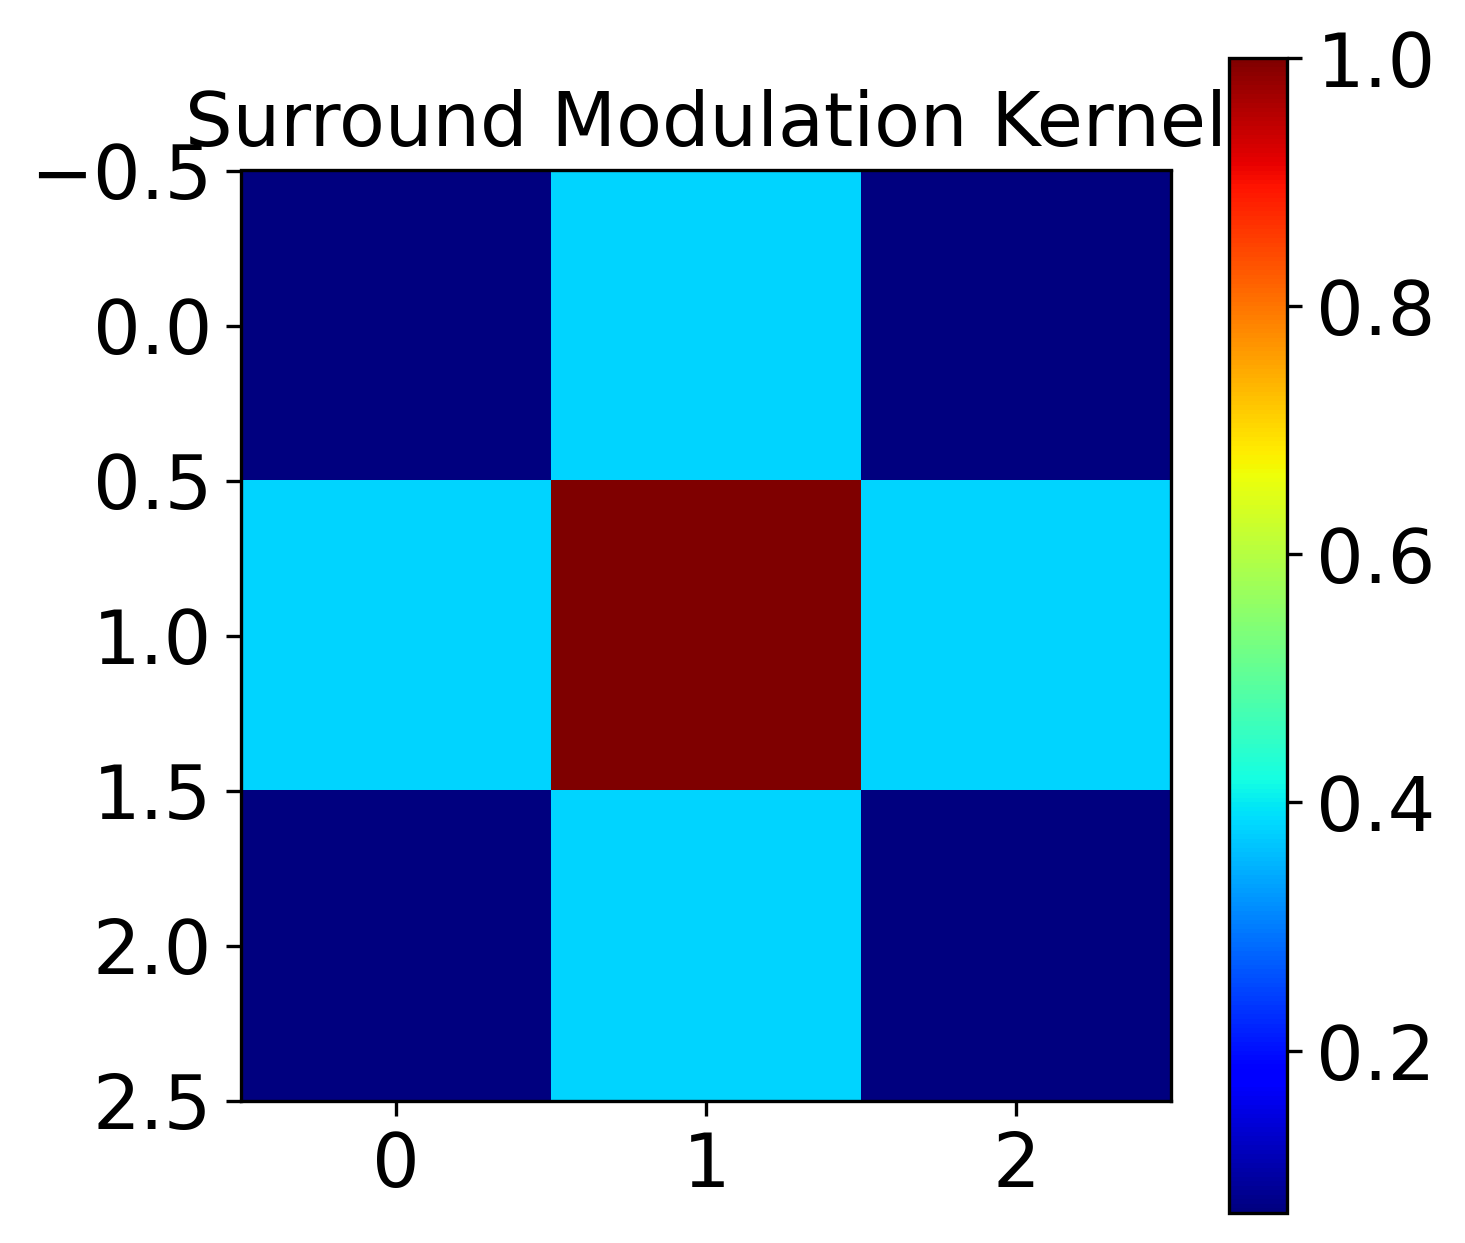

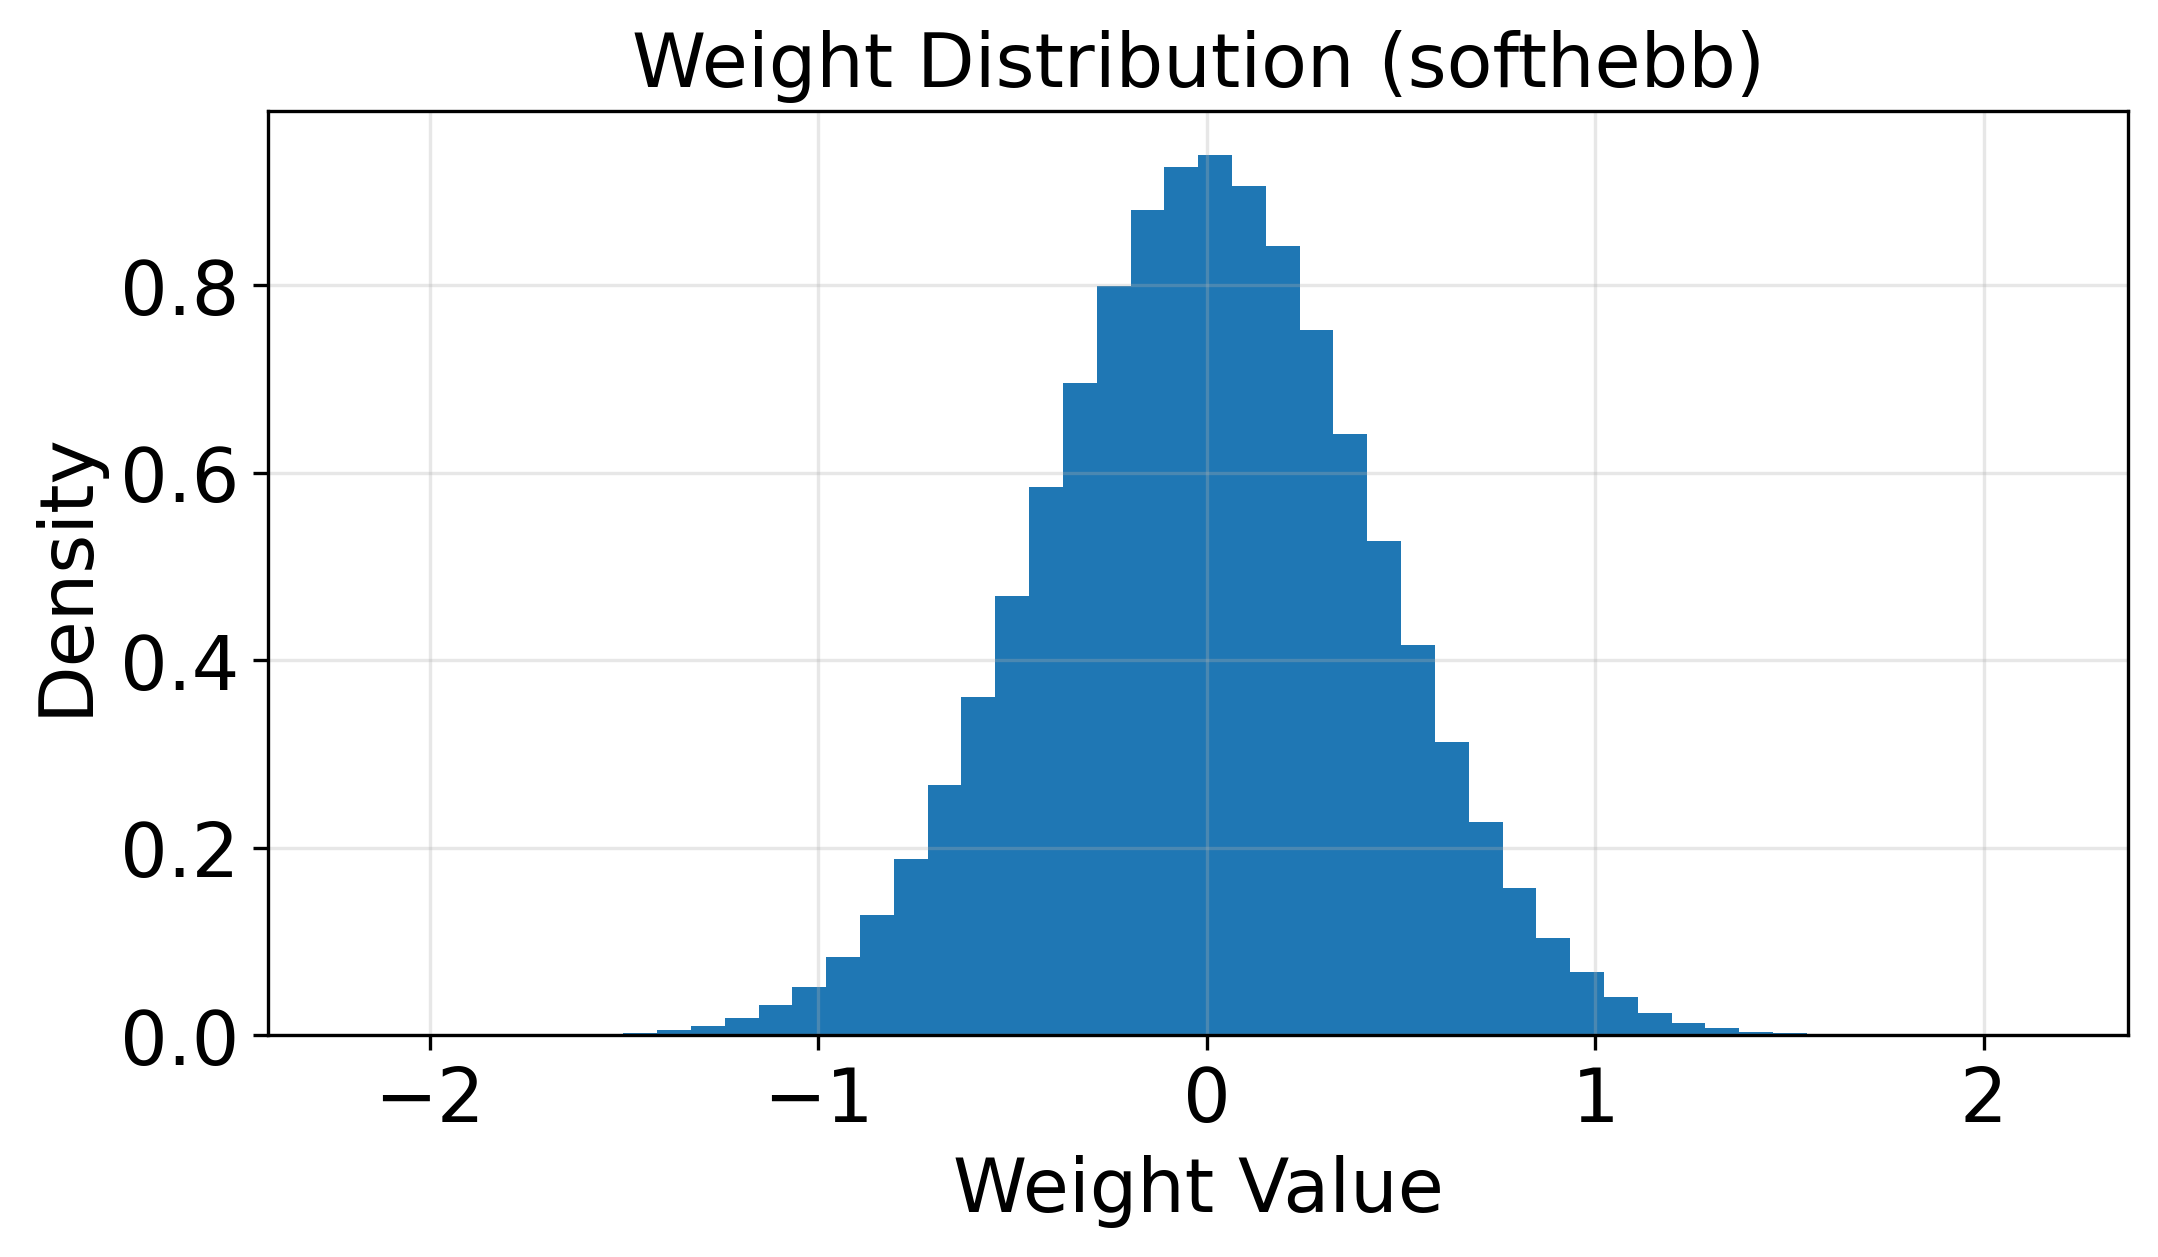

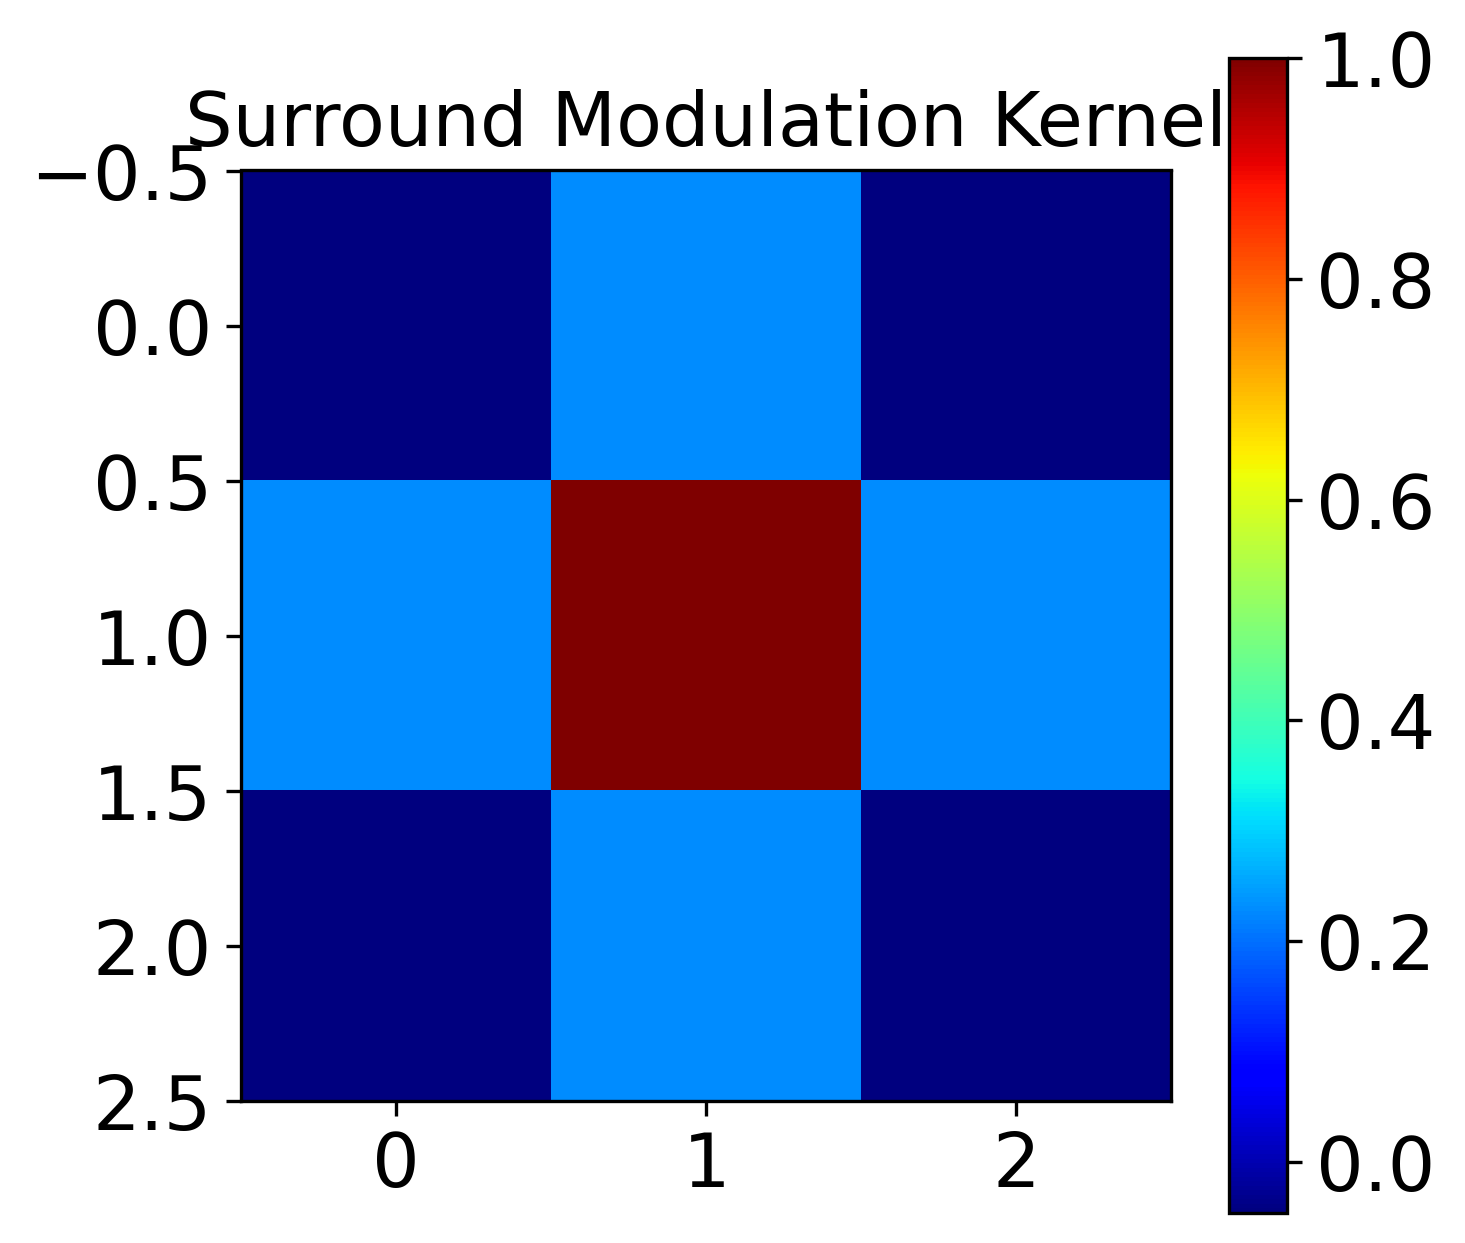

Hebbian epoch 1
Batch 0/782
Batch 100/782
Batch 200/782
Batch 300/782
Batch 400/782
Batch 500/782
Batch 600/782
Batch 700/782
Epoch [1/20] | Train Loss: 1.3816 | Train Acc: 50.87% | Test Loss: 1.1543 | Test Acc: 59.51% | LR: 0.001000
Epoch [2/20] | Train Loss: 1.1243 | Train Acc: 60.57% | Test Loss: 1.0402 | Test Acc: 63.60% | LR: 0.001000
Epoch [3/20] | Train Loss: 1.0541 | Train Acc: 63.19% | Test Loss: 1.0053 | Test Acc: 65.18% | LR: 0.001000
Epoch [4/20] | Train Loss: 1.0103 | Train Acc: 64.53% | Test Loss: 1.0054 | Test Acc: 64.62% | LR: 0.001000
Epoch [5/20] | Train Loss: 0.9808 | Train Acc: 65.88% | Test Loss: 0.9328 | Test Acc: 67.53% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.9615 | Train Acc: 66.37% | Test Loss: 0.9443 | Test Acc: 67.09% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.9554 | Train Acc: 66.52% | Test Loss: 0.9069 | Test Acc: 68.15% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.9378 | Train Acc: 67.21% | Test Loss: 0.9067 | Test Acc: 68.70% | LR: 0.001000
Epoch [9/2

KeyboardInterrupt: 

In [31]:
for seed in seeds:

    print(f"RUN {seed + 1}/5 | SEED = {seed}")
   
    set_seed(seed)

    #fresh model

    hebb_param = get_hebbian_config(version="soft")

    model = Net_Hebbian(
        hebb_params=hebb_param,
        version="softhebb"
    ).to(device)


    # hebbian feature learning ('Unsupervised Feature Learning Phase' trained for 1 epoch)
    model.train()

    for epoch in range(1):

        print(f"Hebbian epoch {epoch + 1}")

        for i, (inputs, _) in enumerate(cifar_loader):

            inputs = inputs.to(device)

            with torch.no_grad():
                model(inputs)

            for layer in [model.conv1, model.conv2, model.conv3]:
                layer.local_update()

            if i % 100 == 0:
                print(f"Batch {i}/{len(cifar_loader)}")
                

    # freeze the hebbian feature extractor as now to train classifier

    for module in [
        model.conv1,
        model.conv2,
        model.conv3,
        model.bn1,
        model.bn2,
        model.bn3
    ]:

        for param in module.parameters():
            param.requires_grad = False

        module.eval()

    #optimiser and schedular as defined in experiment_hebbian.py
    sup_optimizer = torch.optim.Adam(
        model.fc1.parameters(),
        lr=0.001
    )

    scheduler = torch.optim.lr_scheduler.LambdaLR(
        sup_optimizer,
        lr_lambda=lambda epoch:
            0.5 ** max(0, (epoch - 10) // 2)
    )

    criterion = nn.CrossEntropyLoss()


    classifier_history = {
        "train_loss": [],
        "train_accuracy": [],
        "test_loss": [],
        "test_accuracy": []
    }

    #train classier for 20 epochs

    for epoch in range(20):
        model.conv1.eval()
        model.conv2.eval()
        model.conv3.eval()

        model.bn1.eval()
        model.bn2.eval()
        model.bn3.eval()

        model.fc1.train()
        model.dropout.train()

        running_loss = 0.0
        correct = 0
        total = 0


        for inputs, labels in cifar_loader:

            inputs = inputs.to(device)
            labels = labels.to(device)

            sup_optimizer.zero_grad()

            outputs = model(inputs)

            loss = criterion(outputs, labels)

            loss.backward()

            sup_optimizer.step()

            running_loss += loss.item() * labels.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_accuracy = 100 * correct / total

        #get the evaluation results on the test set

        model.eval()

        test_running_loss = 0.0
        test_correct = 0
        test_total = 0

        with torch.no_grad():

            for inputs, labels in cifar_test_loader:

                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)

                loss = criterion(outputs, labels)

                test_running_loss += loss.item() * labels.size(0)

                _, predicted = torch.max(outputs, 1)

                test_total += labels.size(0)
                test_correct += (predicted == labels).sum().item()

        test_loss = test_running_loss / test_total
        test_accuracy = 100 * test_correct / test_total


        classifier_history["train_loss"].append(train_loss)
        classifier_history["train_accuracy"].append(train_accuracy)

        classifier_history["test_loss"].append(test_loss)
        classifier_history["test_accuracy"].append(test_accuracy)

        #update the scheduler
        scheduler.step()

        current_lr = sup_optimizer.param_groups[0]["lr"]

        print(
            f"Epoch [{epoch + 1}/20] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.2f}% | "
            f"Test Loss: {test_loss:.4f} | "
            f"Test Acc: {test_accuracy:.2f}% | "
            f"LR: {current_lr:.6f}"
        )

    # Save this run's history
    all_histories[seed] = classifier_history

# save results and visualise

In [ ]:
all_histories[0]

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
for i in range(seeds):
    all_histories[i].to_csv("/content/drive/MyDrive/research_jobs/hebbian_3_layer_seed_"+i+".csv",
    index=False
)


In [ ]:
epochs = range(1, len(classifier_history["train_loss"]) + 1)

plt.figure(figsize=(4, 2))
plt.plot(epochs, classifier_history["train_loss"])
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Classifier training loss")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, classifier_history["train_accuracy"])
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Classifier training accuracy")
plt.show()

In [ ]:
criterion = nn.CrossEntropyLoss()

classifier_history = {
    "train_loss": [],
    "train_accuracy": [],
    "test_loss": [],
    "test_accuracy": []
}

for epoch in range(20):

    #training

    # Only classifier is being trained
    model.fc1.train()
    model.dropout.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in cifar_loader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        sup_optimizer.zero_grad()

        outputs = model(inputs)

        loss = criterion(outputs, labels)

        loss.backward()
        sup_optimizer.step()

        running_loss += loss.item() * labels.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / total
    train_accuracy = 100 * correct / total


    # testing


    model.eval()

    test_running_loss = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():

        for inputs, labels in cifar_test_loader:

            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)

            loss = criterion(outputs, labels)

            test_running_loss += loss.item() * labels.size(0)

            _, predicted = torch.max(outputs, 1)

            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()

    test_loss = test_running_loss / test_total
    test_accuracy = 100 * test_correct / test_total


    # ==========================================================
    # STORE RESULTS
    # ==========================================================

    classifier_history["train_loss"].append(train_loss)
    classifier_history["train_accuracy"].append(train_accuracy)

    classifier_history["test_loss"].append(test_loss)
    classifier_history["test_accuracy"].append(test_accuracy)


    # ==========================================================
    # LEARNING-RATE SCHEDULER
    # ==========================================================

    scheduler.step()


    # Current learning rate
    current_lr = sup_optimizer.param_groups[0]["lr"]

    print(
        f"Epoch [{epoch + 1}/20] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.2f}% | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_accuracy:.2f}% | "
        f"LR: {current_lr:.6f}"
    )

Epoch [1/20] | Train Loss: 1.4399 | Train Acc: 48.78% | Test Loss: 1.1660 | Test Acc: 59.32% | LR: 0.001000
Epoch [2/20] | Train Loss: 1.1649 | Train Acc: 59.01% | Test Loss: 1.0845 | Test Acc: 61.89% | LR: 0.001000
Epoch [3/20] | Train Loss: 1.0851 | Train Acc: 62.05% | Test Loss: 1.0268 | Test Acc: 64.06% | LR: 0.001000
Epoch [4/20] | Train Loss: 1.0451 | Train Acc: 63.63% | Test Loss: 0.9903 | Test Acc: 65.38% | LR: 0.001000
Epoch [5/20] | Train Loss: 1.0141 | Train Acc: 64.42% | Test Loss: 0.9933 | Test Acc: 65.39% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.9896 | Train Acc: 65.42% | Test Loss: 0.9903 | Test Acc: 64.98% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.9816 | Train Acc: 65.69% | Test Loss: 0.9134 | Test Acc: 68.35% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.9732 | Train Acc: 66.05% | Test Loss: 0.9192 | Test Acc: 68.20% | LR: 0.001000
Epoch [9/20] | Train Loss: 0.9577 | Train Acc: 66.48% | Test Loss: 0.9115 | Test Acc: 68.74% | LR: 0.001000
Epoch [10/20] | Train Loss: 

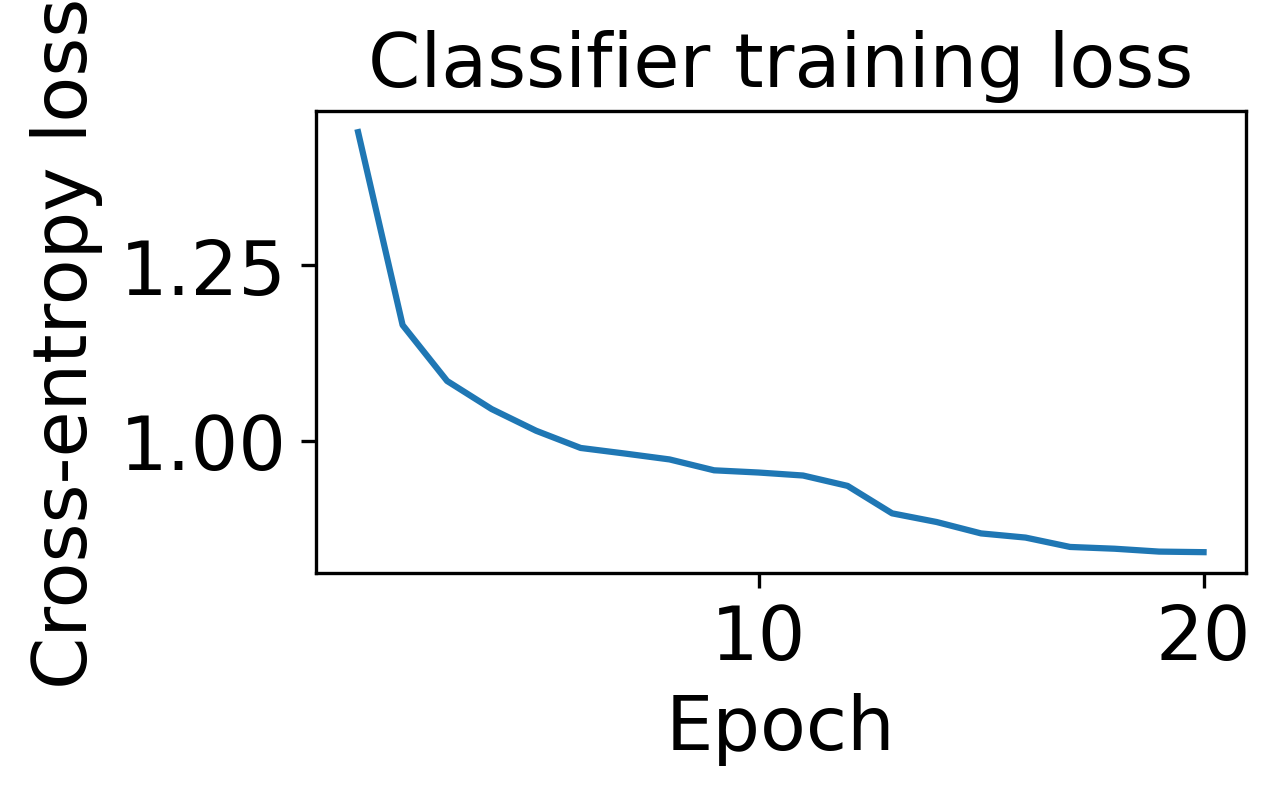

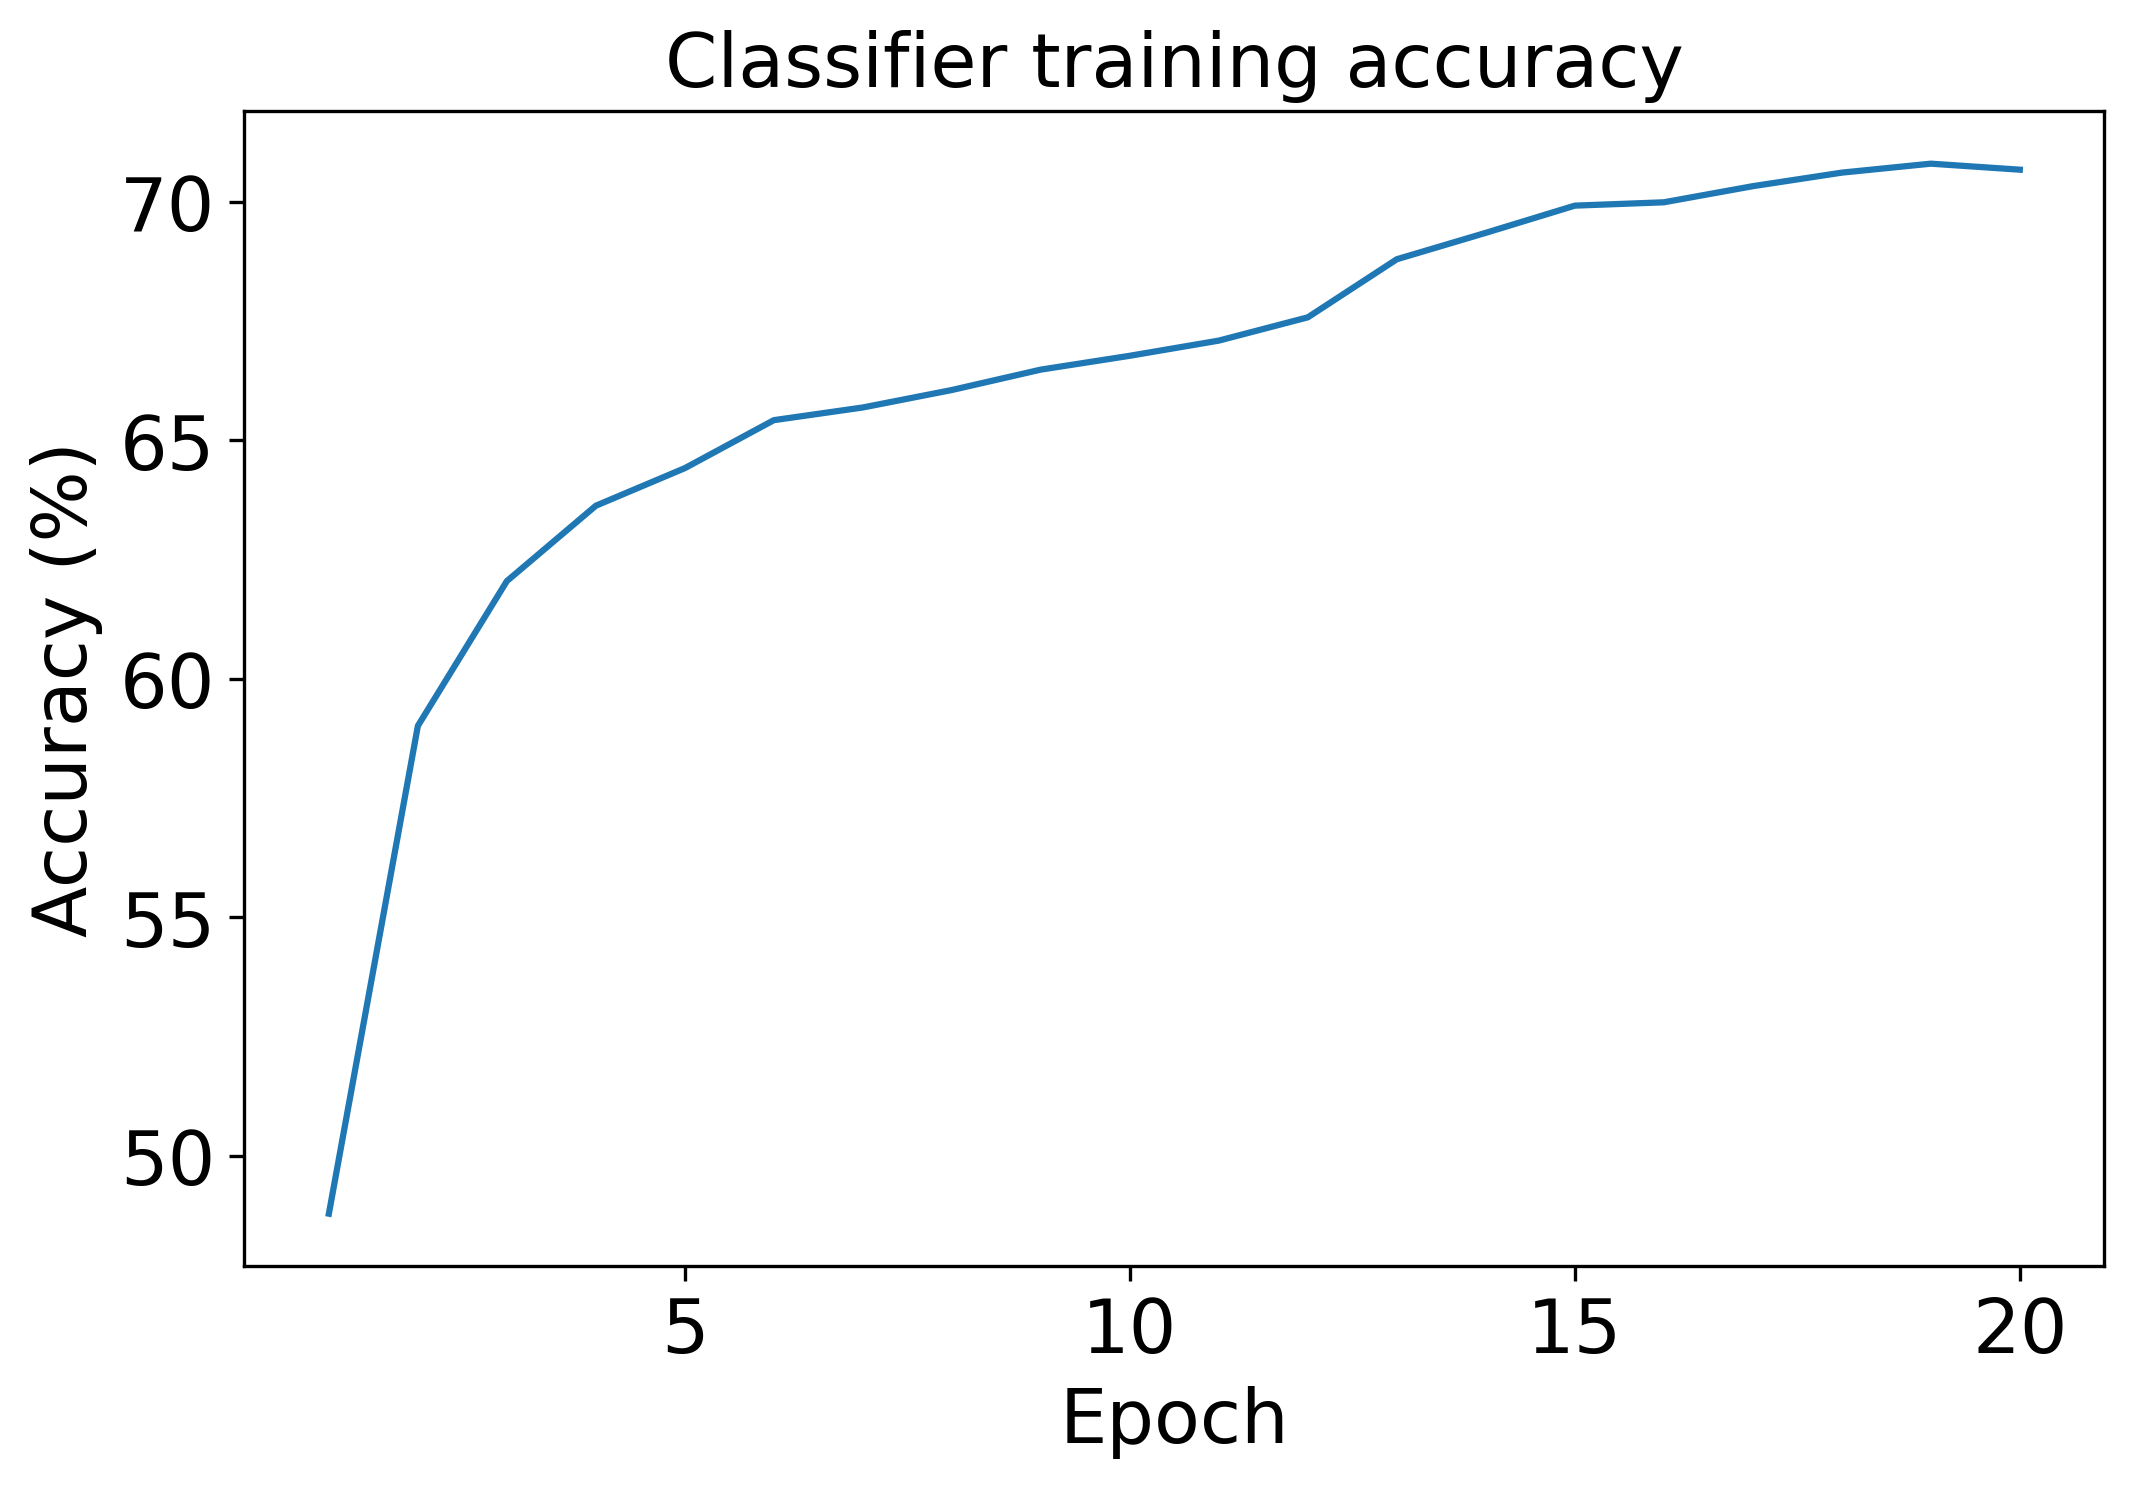

In [41]:
epochs = range(1, len(classifier_history["train_loss"]) + 1)

plt.figure(figsize=(4, 2))
plt.plot(epochs, classifier_history["train_loss"])
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Classifier training loss")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, classifier_history["train_accuracy"])
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Classifier training accuracy")
plt.show()